# 03 — Multilayer Network Features

## Purpose

This notebook implements and adapts the spatial multilayer-network methodology proposed in *A multilayer network framework for soccer analysis*.

The method represents one football match as two interacting spatial networks:

- one passing-network layer for the home team;
- one passing-network layer for the away team;
- intra-layer links representing passes between pitch regions;
- inter-layer links representing changes of possession between the teams.

The original paper divides the pitch into a \(4 \times 5\) spatial grid, producing 20 pitch-region nodes for each team and 40 nodes in the complete two-layer network.

The main paper-derived quantities are:

- eigenvector centrality;
- leakage;
- recovery;
- switching factor.

This project uses StatsBomb event data rather than the Opta data used in the paper. The implementation is therefore described as a methodological reimplementation and predictive adaptation rather than an exact data replication.

## Relationship to the dissertation

The network measures calculated from a completed match will not be used to predict that same match.

Instead, the match-level measures will later be aggregated across each team’s previous completed fixtures to create leakage-safe pre-match features.

The workflow is:

```text
Completed historical match events
        ↓
Spatial multilayer network
        ↓
Match-level network measures
        ↓
Rolling historical aggregation
        ↓
Pre-match model features

In [1]:
# -------------------------------------------------------------------------
# IMPORTS
# -------------------------------------------------------------------------

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx


# -------------------------------------------------------------------------
# CONFIGURATION
# -------------------------------------------------------------------------

CONFIG = {
    "SEED": 42,

    "MATCH_INPUT_PATH": (
        "../data/processed/"
        "integrated_matches_laliga_2015_2016.parquet"
    ),

    "EVENT_INPUT_PATH": (
        "../data/processed/"
        "events_laliga_2015_2016.parquet"
    ),

    "NETWORK_OUTPUT_PATH": (
        "../data/processed/"
        "multilayer_network_metrics_laliga_2015_2016.parquet"
    ),

    # StatsBomb nominal pitch dimensions
    "PITCH_LENGTH": 120.0,
    "PITCH_WIDTH": 80.0,

    # Paper grid: h = 4 and v = 5
    "GRID_X_BINS": 4,
    "GRID_Y_BINS": 5,

    # A completed StatsBomb pass normally has a missing pass_outcome.
    "COMPLETED_PASS_OUTCOME_IS_MISSING": True,
}


# -------------------------------------------------------------------------
# REPRODUCIBILITY AND DISPLAY
# -------------------------------------------------------------------------

np.random.seed(CONFIG["SEED"])

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Multilayer-network environment initialized.")
print(
    f"Pitch grid: "
    f"{CONFIG['GRID_X_BINS']} × {CONFIG['GRID_Y_BINS']}"
)
print(
    f"Nodes per team: "
    f"{CONFIG['GRID_X_BINS'] * CONFIG['GRID_Y_BINS']}"
)

Multilayer-network environment initialized.
Pitch grid: 4 × 5
Nodes per team: 20


In [2]:
# -------------------------------------------------------------------------
# PROJECT PATHS
# -------------------------------------------------------------------------

MATCH_INPUT_PATH = Path(CONFIG["MATCH_INPUT_PATH"])
EVENT_INPUT_PATH = Path(CONFIG["EVENT_INPUT_PATH"])
NETWORK_OUTPUT_PATH = Path(CONFIG["NETWORK_OUTPUT_PATH"])

NETWORK_OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

if not MATCH_INPUT_PATH.exists():
    raise FileNotFoundError(
        "The processed Phase 1 match table was not found:\n"
        f"{MATCH_INPUT_PATH.resolve()}"
    )

if not EVENT_INPUT_PATH.exists():
    raise FileNotFoundError(
        "The processed full-season event table was not found:\n"
        f"{EVENT_INPUT_PATH.resolve()}\n"
        "Complete notebook 02 before continuing."
    )

print("Input paths validated.")
print(f"Matches : {MATCH_INPUT_PATH.resolve()}")
print(f"Events  : {EVENT_INPUT_PATH.resolve()}")
print(f"Output  : {NETWORK_OUTPUT_PATH.resolve()}")

Input paths validated.
Matches : /home/sina/Documents/Arshad/Spring - 2026/Machine Learning/home works/Project/data/processed/integrated_matches_laliga_2015_2016.parquet
Events  : /home/sina/Documents/Arshad/Spring - 2026/Machine Learning/home works/Project/data/processed/events_laliga_2015_2016.parquet
Output  : /home/sina/Documents/Arshad/Spring - 2026/Machine Learning/home works/Project/data/processed/multilayer_network_metrics_laliga_2015_2016.parquet


## Loading the processed match and event tables

The network pipeline uses the processed outputs of the first two notebooks.

The match table provides:

- fixture identity;
- match date;
- home and away team labels;
- final scores;
- future chronological feature-engineering context.

The event table provides:

- event order;
- team identity;
- event type;
- spatial coordinates;
- pass end coordinates;
- possession information.

The network construction must preserve the original `match_id` so that every network measure remains linked to its parent fixture.

In [3]:
# -------------------------------------------------------------------------
# LOAD PROCESSED DATA
# -------------------------------------------------------------------------

matches_df = pd.read_parquet(MATCH_INPUT_PATH)
events_df = pd.read_parquet(EVENT_INPUT_PATH)

matches_df["clean_date"] = pd.to_datetime(
    matches_df["clean_date"],
    errors="raise",
)

events_df["match_date"] = pd.to_datetime(
    events_df["match_date"],
    errors="raise",
)

matches_df = matches_df.sort_values(
    ["clean_date", "match_id"]
).reset_index(drop=True)

events_df = events_df.sort_values(
    ["match_date", "match_id", "period", "index"]
).reset_index(drop=True)

print("Processed datasets loaded.")
print(f"Matches: {len(matches_df):,}")
print(f"Events : {len(events_df):,}")
print(f"Event matches: {events_df['match_id'].nunique():,}")
print(f"Event columns: {len(events_df.columns):,}")

Processed datasets loaded.
Matches: 380
Events : 1,295,354
Event matches: 380
Event columns: 74


In [4]:
# -------------------------------------------------------------------------
# INPUT SCHEMA VALIDATION
# -------------------------------------------------------------------------

required_match_columns = {
    "match_id",
    "clean_date",
    "home_team",
    "away_team",
    "home_score",
    "away_score",
}

required_event_columns = {
    "match_id",
    "match_date",
    "home_team",
    "away_team",
    "id",
    "index",
    "period",
    "minute",
    "second",
    "type",
    "team",
    "location_x",
    "location_y",
    "pass_end_x",
    "pass_end_y",
    "pass_outcome",
}

missing_match_columns = (
    required_match_columns - set(matches_df.columns)
)

missing_event_columns = (
    required_event_columns - set(events_df.columns)
)

if missing_match_columns:
    raise ValueError(
        "Missing required match columns: "
        f"{sorted(missing_match_columns)}"
    )

if missing_event_columns:
    raise ValueError(
        "Missing required event columns: "
        f"{sorted(missing_event_columns)}"
    )

assert matches_df["match_id"].is_unique
assert matches_df["match_id"].notna().all()
assert events_df["match_id"].notna().all()
assert events_df["id"].notna().all()
assert not events_df["id"].duplicated().any()

match_ids = set(matches_df["match_id"].astype(int))
event_match_ids = set(events_df["match_id"].astype(int))

assert match_ids == event_match_ids, (
    "The match and event tables do not contain the same match IDs."
)

print("Input schema validation passed.")
print(f"Validated match IDs: {len(match_ids):,}")

Input schema validation passed.
Validated match IDs: 380


In [5]:
# -------------------------------------------------------------------------
# SPATIAL GRID PARAMETERS
# -------------------------------------------------------------------------

PITCH_LENGTH = CONFIG["PITCH_LENGTH"]
PITCH_WIDTH = CONFIG["PITCH_WIDTH"]

GRID_X_BINS = CONFIG["GRID_X_BINS"]
GRID_Y_BINS = CONFIG["GRID_Y_BINS"]

N_ZONES = GRID_X_BINS * GRID_Y_BINS

ZONE_LENGTH = PITCH_LENGTH / GRID_X_BINS
ZONE_WIDTH = PITCH_WIDTH / GRID_Y_BINS

X_EDGES = np.linspace(
    0.0,
    PITCH_LENGTH,
    GRID_X_BINS + 1,
)

Y_EDGES = np.linspace(
    0.0,
    PITCH_WIDTH,
    GRID_Y_BINS + 1,
)

print(f"Number of zones : {N_ZONES}")
print(f"Zone length     : {ZONE_LENGTH:.2f}")
print(f"Zone width      : {ZONE_WIDTH:.2f}")
print(f"X boundaries    : {X_EDGES}")
print(f"Y boundaries    : {Y_EDGES}")

assert N_ZONES == 20
assert np.isclose(ZONE_LENGTH, 30.0)
assert np.isclose(ZONE_WIDTH, 16.0)

Number of zones : 20
Zone length     : 30.00
Zone width      : 16.00
X boundaries    : [  0.  30.  60.  90. 120.]
Y boundaries    : [ 0. 16. 32. 48. 64. 80.]


In [6]:
# -------------------------------------------------------------------------
# COORDINATE-TO-ZONE FUNCTION
# -------------------------------------------------------------------------

def coordinate_to_zone(
    x,
    y,
    pitch_length=120.0,
    pitch_width=80.0,
    x_bins=4,
    y_bins=5,
):
    """
    Convert one pitch coordinate into a zero-based spatial zone.

    Zones are numbered row by row:

        zone = y_bin * x_bins + x_bin

    Parameters
    ----------
    x : float
        Longitudinal pitch coordinate.

    y : float
        Lateral pitch coordinate.

    Returns
    -------
    int or pd.NA
        Zone number from 0 to 19, or missing if coordinates
        are unavailable or invalid.
    """

    if pd.isna(x) or pd.isna(y):
        return pd.NA

    try:
        x = float(x)
        y = float(y)
    except (TypeError, ValueError):
        return pd.NA

    if not (0.0 <= x <= pitch_length):
        return pd.NA

    if not (0.0 <= y <= pitch_width):
        return pd.NA

    zone_length = pitch_length / x_bins
    zone_width = pitch_width / y_bins

    x_bin = int(np.floor(x / zone_length))
    y_bin = int(np.floor(y / zone_width))

    # Upper boundaries belong to the final valid bin.
    x_bin = int(np.clip(x_bin, 0, x_bins - 1))
    y_bin = int(np.clip(y_bin, 0, y_bins - 1))

    zone = y_bin * x_bins + x_bin

    return int(zone)

In [7]:
# -------------------------------------------------------------------------
# UNIT TESTS FOR ZONE ASSIGNMENT
# -------------------------------------------------------------------------

zone_tests = [
    # Bottom-left corner
    ((0.0, 0.0), 0),

    # First zone interior
    ((10.0, 10.0), 0),

    # Final x-bin, first y-band
    ((119.9, 10.0), 3),

    # Second y-band, first x-bin
    ((10.0, 20.0), 4),

    # Approximate pitch centre
    ((60.0, 40.0), 10),

    # Exact top-right boundary
    ((120.0, 80.0), 19),
]

for (x, y), expected_zone in zone_tests:

    calculated_zone = coordinate_to_zone(x, y)

    assert calculated_zone == expected_zone, (
        f"Coordinate ({x}, {y}) was assigned to "
        f"zone {calculated_zone}, expected {expected_zone}."
    )

print("Coordinate-to-zone unit tests passed.")

Coordinate-to-zone unit tests passed.


In [8]:
# -------------------------------------------------------------------------
# ZONE REFERENCE TABLE
# -------------------------------------------------------------------------

zone_reference_records = []

for y_bin in range(GRID_Y_BINS):
    for x_bin in range(GRID_X_BINS):

        zone_id = y_bin * GRID_X_BINS + x_bin

        zone_reference_records.append(
            {
                "zone_id": zone_id,
                "x_bin": x_bin,
                "y_bin": y_bin,
                "x_min": X_EDGES[x_bin],
                "x_max": X_EDGES[x_bin + 1],
                "y_min": Y_EDGES[y_bin],
                "y_max": Y_EDGES[y_bin + 1],
                "x_center": (
                    X_EDGES[x_bin]
                    + X_EDGES[x_bin + 1]
                ) / 2,
                "y_center": (
                    Y_EDGES[y_bin]
                    + Y_EDGES[y_bin + 1]
                ) / 2,
            }
        )

zone_reference_df = pd.DataFrame(
    zone_reference_records
)

assert len(zone_reference_df) == 20
assert zone_reference_df["zone_id"].is_unique

display(zone_reference_df)

,zone_id,x_bin,y_bin,x_min,x_max,y_min,y_max,x_center,y_center
0,0,0,0,0.0,30.0,0.0,16.0,15.0,8.0
1,1,1,0,30.0,60.0,0.0,16.0,45.0,8.0
2,2,2,0,60.0,90.0,0.0,16.0,75.0,8.0
3,3,3,0,90.0,120.0,0.0,16.0,105.0,8.0
4,4,0,1,0.0,30.0,16.0,32.0,15.0,24.0
5,5,1,1,30.0,60.0,16.0,32.0,45.0,24.0
6,6,2,1,60.0,90.0,16.0,32.0,75.0,24.0
7,7,3,1,90.0,120.0,16.0,32.0,105.0,24.0
8,8,0,2,0.0,30.0,32.0,48.0,15.0,40.0
9,9,1,2,30.0,60.0,32.0,48.0,45.0,40.0


In [9]:
# -------------------------------------------------------------------------
# SAMPLE MATCH SELECTION
# -------------------------------------------------------------------------

sample_match = matches_df.iloc[0]

SAMPLE_MATCH_ID = int(sample_match["match_id"])
SAMPLE_HOME_TEAM = str(sample_match["home_team"])
SAMPLE_AWAY_TEAM = str(sample_match["away_team"])

sample_match_events_df = events_df[
    events_df["match_id"] == SAMPLE_MATCH_ID
].copy()

assert not sample_match_events_df.empty

observed_teams = set(
    sample_match_events_df["team"].dropna().unique()
)

expected_teams = {
    SAMPLE_HOME_TEAM,
    SAMPLE_AWAY_TEAM,
}

assert observed_teams == expected_teams, (
    "The event-team labels do not match the fixture labels.\n"
    f"Expected: {expected_teams}\n"
    f"Observed: {observed_teams}"
)

print("Sample match selected.")
print(f"Match ID: {SAMPLE_MATCH_ID}")
print(
    f"Fixture : {SAMPLE_HOME_TEAM} vs {SAMPLE_AWAY_TEAM}"
)
print(f"Events  : {len(sample_match_events_df):,}")

Sample match selected.
Match ID: 3825562
Fixture : Málaga vs Sevilla
Events  : 2,750


In [10]:
# -------------------------------------------------------------------------
# SAMPLE MATCH PASS EVENTS
# -------------------------------------------------------------------------

sample_passes_df = sample_match_events_df[
    sample_match_events_df["type"] == "Pass"
].copy()

assert not sample_passes_df.empty

print(f"All pass events: {len(sample_passes_df):,}")
print("\nPass outcomes:")

display(
    sample_passes_df["pass_outcome"]
    .value_counts(dropna=False)
    .rename_axis("pass_outcome")
    .reset_index(name="pass_count")
)

All pass events: 771

Pass outcomes:


,pass_outcome,pass_count
0,None,572
1,Incomplete,161
2,Out,26
3,Unknown,6
4,Pass Offside,4
5,Injury Clearance,2


In [11]:
# -------------------------------------------------------------------------
# COMPLETED PASS SELECTION
# -------------------------------------------------------------------------

sample_completed_passes_df = sample_passes_df[
    sample_passes_df["pass_outcome"].isna()
].copy()

required_pass_coordinates = [
    "location_x",
    "location_y",
    "pass_end_x",
    "pass_end_y",
]

complete_coordinate_mask = (
    sample_completed_passes_df[
        required_pass_coordinates
    ]
    .notna()
    .all(axis=1)
)

passes_missing_coordinates = int(
    (~complete_coordinate_mask).sum()
)

sample_completed_passes_df = (
    sample_completed_passes_df[
        complete_coordinate_mask
    ]
    .copy()
)

print(
    f"Completed passes with valid coordinates: "
    f"{len(sample_completed_passes_df):,}"
)
print(
    f"Completed passes excluded for missing coordinates: "
    f"{passes_missing_coordinates:,}"
)

assert not sample_completed_passes_df.empty

Completed passes with valid coordinates: 572
Completed passes excluded for missing coordinates: 0


In [12]:
# -------------------------------------------------------------------------
# ASSIGN PASS START AND END ZONES
# -------------------------------------------------------------------------

sample_completed_passes_df["start_zone"] = [
    coordinate_to_zone(x, y)
    for x, y in zip(
        sample_completed_passes_df["location_x"],
        sample_completed_passes_df["location_y"],
    )
]

sample_completed_passes_df["end_zone"] = [
    coordinate_to_zone(x, y)
    for x, y in zip(
        sample_completed_passes_df["pass_end_x"],
        sample_completed_passes_df["pass_end_y"],
    )
]

sample_completed_passes_df["start_zone"] = (
    sample_completed_passes_df["start_zone"]
    .astype("Int64")
)

sample_completed_passes_df["end_zone"] = (
    sample_completed_passes_df["end_zone"]
    .astype("Int64")
)

assert sample_completed_passes_df["start_zone"].notna().all()
assert sample_completed_passes_df["end_zone"].notna().all()

assert sample_completed_passes_df["start_zone"].between(
    0,
    N_ZONES - 1,
).all()

assert sample_completed_passes_df["end_zone"].between(
    0,
    N_ZONES - 1,
).all()

print("Pass-zone assignment passed.")
print(
    f"Observed start zones: "
    f"{sample_completed_passes_df['start_zone'].nunique()}"
)
print(
    f"Observed end zones  : "
    f"{sample_completed_passes_df['end_zone'].nunique()}"
)

display(
    sample_completed_passes_df[
        [
            "team",
            "player",
            "location_x",
            "location_y",
            "start_zone",
            "pass_end_x",
            "pass_end_y",
            "end_zone",
        ]
    ].head(10)
)

Pass-zone assignment passed.
Observed start zones: 20
Observed end zones  : 20


,team,player,location_x,location_y,start_zone,pass_end_x,pass_end_y,end_zone
4,Málaga,Duje Čop,60.0,40.0,10,59.4,42.2,9
6,Málaga,Charles Días Barbosa de Oliveira,59.4,39.4,9,41.8,36.1,9
8,Málaga,Sergi Darder Moll,42.4,32.2,9,40.8,6.6,1
11,Málaga,Arthur Etienne Boka,38.1,11.0,1,28.7,37.8,8
23,Sevilla,Steven N''Kemboanza Mike Christopher Nzonzi,62.2,58.5,14,54.3,74.4,17
26,Sevilla,Jorge Andújar Moreno,48.9,73.7,17,33.1,60.2,13
32,Málaga,Nordin Amrabat,87.4,0.1,2,84.5,9.1,2
38,Sevilla,Grzegorz Krychowiak,17.3,51.6,12,31.6,16.7,5
41,Sevilla,Benoît Trémoulinas,32.0,18.1,5,25.0,36.7,8
44,Sevilla,Steven N''Kemboanza Mike Christopher Nzonzi,25.4,42.5,8,45.4,76.0,17


In [13]:
# -------------------------------------------------------------------------
# TEAM PASSING ADJACENCY MATRIX
# -------------------------------------------------------------------------

def build_passing_adjacency_matrix(
    completed_passes_df,
    team_name,
    n_zones=20,
):
    """
    Build a weighted directed pitch-passing adjacency matrix.

    Matrix element A[i, j] equals the number of completed passes
    made by the selected team from spatial zone i to spatial zone j.
    """

    team_passes_df = completed_passes_df[
        completed_passes_df["team"] == team_name
    ].copy()

    if team_passes_df.empty:
        raise ValueError(
            f"No completed passes found for team: {team_name}"
        )

    adjacency_matrix = np.zeros(
        (n_zones, n_zones),
        dtype=np.int64,
    )

    for start_zone, end_zone in zip(
        team_passes_df["start_zone"],
        team_passes_df["end_zone"],
    ):
        adjacency_matrix[
            int(start_zone),
            int(end_zone),
        ] += 1

    return adjacency_matrix

In [14]:
# -------------------------------------------------------------------------
# SAMPLE HOME AND AWAY PASSING MATRICES
# -------------------------------------------------------------------------

home_adjacency = build_passing_adjacency_matrix(
    completed_passes_df=sample_completed_passes_df,
    team_name=SAMPLE_HOME_TEAM,
    n_zones=N_ZONES,
)

away_adjacency = build_passing_adjacency_matrix(
    completed_passes_df=sample_completed_passes_df,
    team_name=SAMPLE_AWAY_TEAM,
    n_zones=N_ZONES,
)

assert home_adjacency.shape == (20, 20)
assert away_adjacency.shape == (20, 20)

home_completed_pass_count = (
    sample_completed_passes_df["team"]
    .eq(SAMPLE_HOME_TEAM)
    .sum()
)

away_completed_pass_count = (
    sample_completed_passes_df["team"]
    .eq(SAMPLE_AWAY_TEAM)
    .sum()
)

assert home_adjacency.sum() == home_completed_pass_count
assert away_adjacency.sum() == away_completed_pass_count

print("Sample passing matrices constructed.")
print(
    f"{SAMPLE_HOME_TEAM} completed passes: "
    f"{home_adjacency.sum():,}"
)
print(
    f"{SAMPLE_AWAY_TEAM} completed passes: "
    f"{away_adjacency.sum():,}"
)
print(
    f"{SAMPLE_HOME_TEAM} active directed edges: "
    f"{np.count_nonzero(home_adjacency):,}"
)
print(
    f"{SAMPLE_AWAY_TEAM} active directed edges: "
    f"{np.count_nonzero(away_adjacency):,}"
)

Sample passing matrices constructed.
Málaga completed passes: 331
Sevilla completed passes: 241
Málaga active directed edges: 123
Sevilla active directed edges: 119


In [15]:
# -------------------------------------------------------------------------
# DISPLAY SAMPLE PASSING MATRICES
# -------------------------------------------------------------------------

zone_labels = [
    f"Z{zone_id:02d}"
    for zone_id in range(N_ZONES)
]

home_adjacency_df = pd.DataFrame(
    home_adjacency,
    index=zone_labels,
    columns=zone_labels,
)

away_adjacency_df = pd.DataFrame(
    away_adjacency,
    index=zone_labels,
    columns=zone_labels,
)

print(f"{SAMPLE_HOME_TEAM} adjacency matrix")
display(home_adjacency_df)

print(f"{SAMPLE_AWAY_TEAM} adjacency matrix")
display(away_adjacency_df)

Málaga adjacency matrix


,Z00,Z01,Z02,Z03,Z04,Z05,Z06,Z07,Z08,Z09,Z10,Z11,Z12,Z13,Z14,Z15,Z16,Z17,Z18,Z19
Z00,1,3,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
Z01,1,8,2,0,2,2,0,0,2,3,1,0,0,0,0,0,0,0,0,0
Z02,0,4,13,2,0,2,8,2,0,0,0,0,0,0,0,0,0,0,0,1
Z03,0,0,0,6,0,0,1,2,0,0,0,1,0,0,0,0,0,0,0,0
Z04,0,0,1,0,3,1,1,0,0,1,0,0,2,0,0,0,0,0,0,0
Z05,1,3,0,0,1,4,1,0,0,5,1,0,0,4,0,0,0,1,0,0
Z06,0,1,1,1,0,1,10,1,0,0,3,0,0,0,0,0,0,0,0,0
Z07,0,0,1,2,0,0,2,6,0,0,0,2,0,0,0,0,0,0,0,1
Z08,0,0,2,0,2,0,0,0,0,3,0,0,0,2,1,0,2,2,3,0
Z09,0,5,5,0,0,3,0,0,0,5,1,0,0,3,1,0,0,1,2,0


Sevilla adjacency matrix


,Z00,Z01,Z02,Z03,Z04,Z05,Z06,Z07,Z08,Z09,Z10,Z11,Z12,Z13,Z14,Z15,Z16,Z17,Z18,Z19
Z00,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Z01,2,7,1,1,1,3,1,0,1,4,0,0,0,1,0,0,0,0,0,0
Z02,0,2,11,2,0,1,6,0,0,0,0,0,0,0,0,0,0,0,0,2
Z03,0,0,0,4,0,0,0,1,0,0,0,2,0,0,0,0,0,0,0,0
Z04,1,3,0,0,1,2,0,0,3,0,0,0,0,0,0,0,0,0,0,0
Z05,2,6,1,0,1,1,2,0,2,4,1,0,0,1,0,0,0,1,0,0
Z06,0,1,3,2,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1
Z07,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Z08,0,0,0,0,2,0,0,0,1,2,1,0,1,0,7,0,0,3,5,0
Z09,0,4,0,0,0,3,1,0,1,4,1,0,1,2,0,0,1,0,0,0


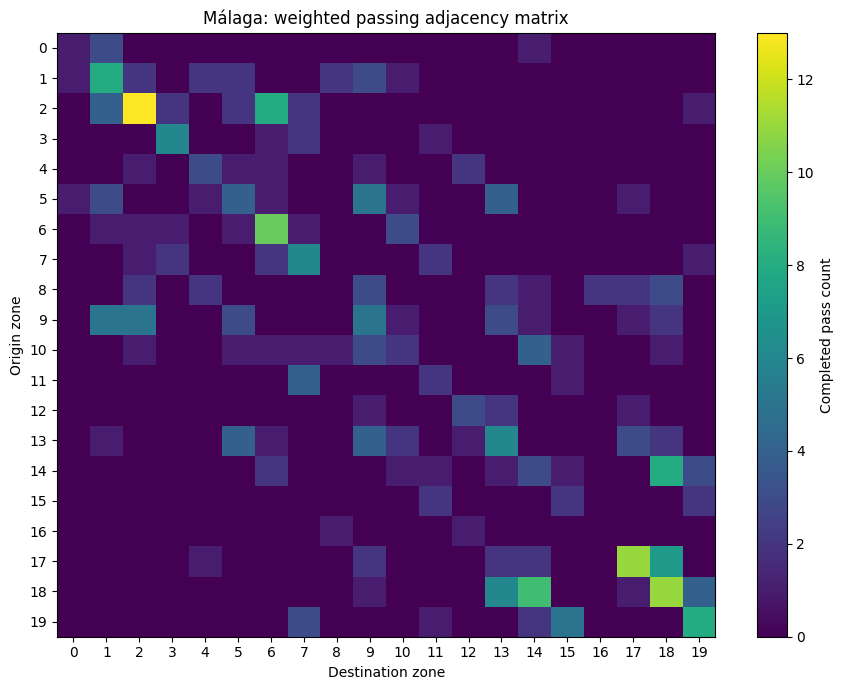

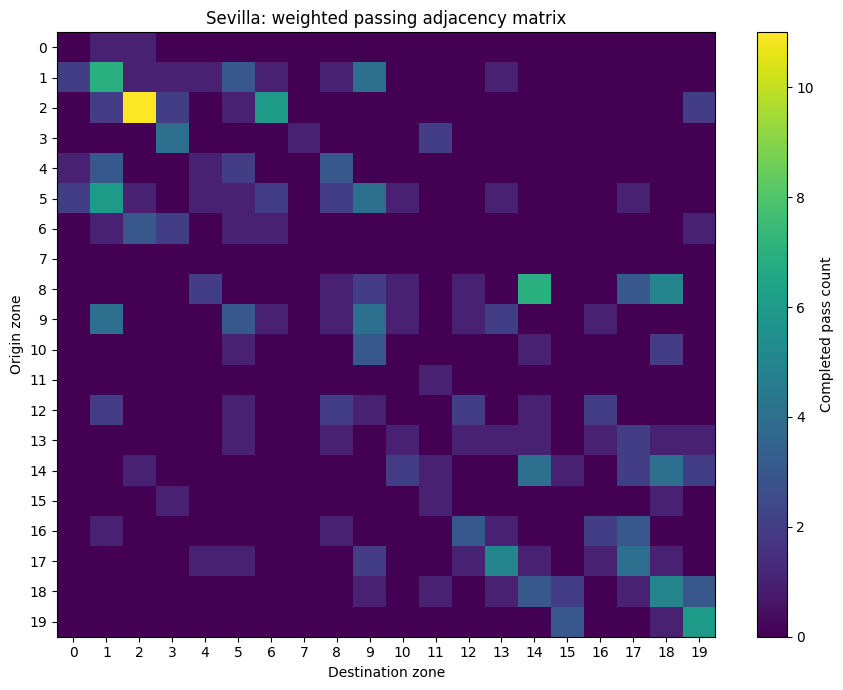

In [16]:
# -------------------------------------------------------------------------
# SAMPLE PASSING-MATRIX HEATMAPS
# -------------------------------------------------------------------------

plt.figure(figsize=(9, 7))
plt.imshow(home_adjacency, aspect="auto")
plt.colorbar(label="Completed pass count")
plt.xlabel("Destination zone")
plt.ylabel("Origin zone")
plt.title(
    f"{SAMPLE_HOME_TEAM}: weighted passing adjacency matrix"
)
plt.xticks(range(N_ZONES), range(N_ZONES))
plt.yticks(range(N_ZONES), range(N_ZONES))
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 7))
plt.imshow(away_adjacency, aspect="auto")
plt.colorbar(label="Completed pass count")
plt.xlabel("Destination zone")
plt.ylabel("Origin zone")
plt.title(
    f"{SAMPLE_AWAY_TEAM}: weighted passing adjacency matrix"
)
plt.xticks(range(N_ZONES), range(N_ZONES))
plt.yticks(range(N_ZONES), range(N_ZONES))
plt.tight_layout()
plt.show()

In [17]:
# -------------------------------------------------------------------------
# CONVERT ADJACENCY MATRICES INTO DIRECTED GRAPHS
# -------------------------------------------------------------------------

home_graph = nx.from_numpy_array(
    home_adjacency,
    create_using=nx.DiGraph,
)

away_graph = nx.from_numpy_array(
    away_adjacency,
    create_using=nx.DiGraph,
)

for node_id, node_row in zone_reference_df.set_index(
    "zone_id"
).iterrows():

    node_attributes = {
        "x_bin": int(node_row["x_bin"]),
        "y_bin": int(node_row["y_bin"]),
        "x_center": float(node_row["x_center"]),
        "y_center": float(node_row["y_center"]),
    }

    home_graph.nodes[int(node_id)].update(
        node_attributes
    )

    away_graph.nodes[int(node_id)].update(
        node_attributes
    )

assert home_graph.number_of_nodes() == 20
assert away_graph.number_of_nodes() == 20

assert home_graph.number_of_edges() == np.count_nonzero(
    home_adjacency
)

assert away_graph.number_of_edges() == np.count_nonzero(
    away_adjacency
)

print("NetworkX directed graphs created.")
print(
    f"{SAMPLE_HOME_TEAM}: "
    f"{home_graph.number_of_nodes()} nodes, "
    f"{home_graph.number_of_edges()} edges"
)
print(
    f"{SAMPLE_AWAY_TEAM}: "
    f"{away_graph.number_of_nodes()} nodes, "
    f"{away_graph.number_of_edges()} edges"
)

NetworkX directed graphs created.
Málaga: 20 nodes, 123 edges
Sevilla: 20 nodes, 119 edges


## Inter-layer possession transitions

The two passing layers describe how each team circulates the ball internally. A multilayer representation also requires links between the two teams.

In the original framework, inter-layer links represent ball or possession transfers between teams. StatsBomb explicitly identifies possession sequences using:

- `possession`;
- `possession_team`;
- `possession_team_id`.

For this adaptation, each possession is summarized using:

- the first valid spatial event in the possession;
- the last valid spatial event in the possession;
- the team assigned possession;
- the pitch zone where possession began;
- the pitch zone where possession ended.

A directed inter-layer edge is created when two consecutive possessions in the same match period belong to different teams.

For example:

```text
Málaga possession ends in zone 14
        ↓
Sevilla possession begins in zone 13

In [18]:

# -------------------------------------------------------------------------
# INSPECT SAMPLE POSSESSION FIELDS
# -------------------------------------------------------------------------

possession_columns = [
    "match_id",
    "period",
    "index",
    "minute",
    "second",
    "type",
    "team",
    "possession",
    "possession_team",
    "play_pattern",
    "location_x",
    "location_y",
]

available_possession_columns = [
    column
    for column in possession_columns
    if column in sample_match_events_df.columns
]

display(
    sample_match_events_df[
        available_possession_columns
    ].head(30)
)

print(
    "Unique possession identifiers: "
    f"{sample_match_events_df['possession'].nunique():,}"
)

print("\nPossession teams:")
display(
    sample_match_events_df[
        ["possession", "possession_team"]
    ]
    .drop_duplicates()
    ["possession_team"]
    .value_counts(dropna=False)
    .rename_axis("possession_team")
    .reset_index(name="possession_count")
)

,match_id,period,index,minute,second,type,team,possession,possession_team,play_pattern,location_x,location_y
0,3825562,1,1,0,0,Starting XI,Málaga,1,Málaga,Regular Play,NaN,NaN
1,3825562,1,2,0,0,Starting XI,Sevilla,1,Málaga,Regular Play,NaN,NaN
2,3825562,1,3,0,0,Half Start,Málaga,1,Málaga,Regular Play,NaN,NaN
3,3825562,1,4,0,0,Half Start,Sevilla,1,Málaga,Regular Play,NaN,NaN
4,3825562,1,5,0,1,Pass,Málaga,2,Málaga,From Kick Off,60.0,40.0
5,3825562,1,6,0,2,Ball Receipt*,Málaga,2,Málaga,From Kick Off,59.4,42.2
6,3825562,1,7,0,2,Pass,Málaga,2,Málaga,From Kick Off,59.4,39.4
7,3825562,1,8,0,3,Ball Receipt*,Málaga,2,Málaga,From Kick Off,41.8,36.1
8,3825562,1,9,0,5,Pass,Málaga,2,Málaga,From Kick Off,42.4,32.2
9,3825562,1,10,0,6,Ball Receipt*,Málaga,2,Málaga,From Kick Off,40.8,6.6


Unique possession identifiers: 176

Possession teams:


,possession_team,possession_count
0,Sevilla,91
1,Málaga,85


In [20]:
# -------------------------------------------------------------------------
# POSSESSION CONSISTENCY VALIDATION
# -------------------------------------------------------------------------

# A possession is uniquely identified within a period, rather than
# necessarily across the entire match.
possession_consistency_df = (
    sample_match_events_df
    .dropna(subset=["period", "possession"])
    .groupby(
        ["period", "possession"],
        as_index=False,
    )
    .agg(
        possession_team_count=(
            "possession_team",
            "nunique",
        ),
        event_count=("id", "size"),
        first_event_index=("index", "min"),
        last_event_index=("index", "max"),
    )
)

invalid_team_possessions = possession_consistency_df[
    possession_consistency_df[
        "possession_team_count"
    ] != 1
]

if not invalid_team_possessions.empty:
    display(invalid_team_possessions)

    raise ValueError(
        "At least one period-possession sequence has "
        "multiple possession-team labels."
    )

duplicate_period_possession_keys = (
    possession_consistency_df[
        ["period", "possession"]
    ]
    .duplicated()
    .sum()
)

assert duplicate_period_possession_keys == 0, (
    "Duplicate period-possession keys remain after aggregation."
)

print("Possession consistency validation passed.")
print(
    "Validated period-possession sequences: "
    f"{len(possession_consistency_df):,}"
)

Possession consistency validation passed.
Validated period-possession sequences: 177


In [63]:
# -------------------------------------------------------------------------
# BOUNDARY-AWARE POSSESSION-SUMMARY FUNCTION
# -------------------------------------------------------------------------

def build_possession_summary(
    match_events_df,
    coordinate_zone_function,
):
    """
    Summarize every period-possession sequence in one match.

    Possession identity:
        match_id + period + possession

    Some StatsBomb events tagged to an earlier possession may appear
    after the next possession begins. Therefore, a possession's spatial
    end is defined as its final valid spatial event occurring before the
    next possession's first chronological event.
    """

    required_columns = {
        "match_id",
        "period",
        "index",
        "possession",
        "possession_team",
        "type",
        "location_x",
        "location_y",
    }

    missing_columns = (
        required_columns
        - set(match_events_df.columns)
    )

    if missing_columns:
        raise ValueError(
            "Cannot build possession summaries. Missing columns: "
            f"{sorted(missing_columns)}"
        )

    if match_events_df.empty:
        raise ValueError(
            "The supplied match event table is empty."
        )

    unique_match_ids = (
        match_events_df["match_id"]
        .dropna()
        .astype(int)
        .unique()
    )

    if len(unique_match_ids) != 1:
        raise ValueError(
            "build_possession_summary expects events "
            "from exactly one match."
        )

    match_id = int(unique_match_ids[0])

    ordered_events_df = (
        match_events_df
        .dropna(
            subset=[
                "period",
                "possession",
                "possession_team",
                "index",
            ]
        )
        .sort_values(
            [
                "period",
                "index",
            ]
        )
        .copy()
    )

    # ---------------------------------------------------------------------
    # DETERMINE THE CHRONOLOGICAL START OF EACH POSSESSION
    # ---------------------------------------------------------------------

    possession_boundaries_df = (
        ordered_events_df
        .groupby(
            [
                "period",
                "possession",
            ],
            as_index=False,
        )
        .agg(
            first_event_index=(
                "index",
                "min",
            ),
        )
        .sort_values(
            [
                "period",
                "first_event_index",
                "possession",
            ]
        )
        .reset_index(drop=True)
    )

    possession_boundaries_df[
        "next_possession_start_index"
    ] = (
        possession_boundaries_df
        .groupby("period")[
            "first_event_index"
        ]
        .shift(-1)
    )

    possession_records = []

    for boundary_row in (
        possession_boundaries_df.itertuples(
            index=False
        )
    ):
        period_id = int(
            boundary_row.period
        )

        possession_id = int(
            boundary_row.possession
        )

        possession_start_index = int(
            boundary_row.first_event_index
        )

        next_possession_start_index = (
            boundary_row.next_possession_start_index
        )

        possession_events_df = (
            ordered_events_df.loc[
                (
                    ordered_events_df["period"]
                    == period_id
                )
                & (
                    ordered_events_df["possession"]
                    == possession_id
                )
            ]
            .sort_values("index")
            .copy()
        )

        if possession_events_df.empty:
            continue

        team_values = (
            possession_events_df[
                "possession_team"
            ]
            .dropna()
            .astype(str)
            .unique()
        )

        if len(team_values) != 1:
            raise ValueError(
                f"Match {match_id}, period {period_id}, "
                f"possession {possession_id} contains "
                "multiple possession-team labels."
            )

        possession_team = str(
            team_values[0]
        )

        # Events tagged to this possession but recorded after the next
        # possession starts are excluded from its spatial endpoint.
        boundary_limited_events_df = (
            possession_events_df.copy()
        )

        if pd.notna(
            next_possession_start_index
        ):
            boundary_limited_events_df = (
                boundary_limited_events_df.loc[
                    boundary_limited_events_df[
                        "index"
                    ]
                    < int(
                        next_possession_start_index
                    )
                ]
                .copy()
            )

        # The possession's first event must remain inside its interval.
        if boundary_limited_events_df.empty:
            boundary_limited_events_df = (
                possession_events_df.loc[
                    possession_events_df[
                        "index"
                    ].eq(
                        possession_start_index
                    )
                ]
                .copy()
            )

        spatial_mask = (
            boundary_limited_events_df[
                [
                    "location_x",
                    "location_y",
                ]
            ]
            .notna()
            .all(axis=1)
        )

        spatial_events_df = (
            boundary_limited_events_df.loc[
                spatial_mask
            ]
            .sort_values("index")
            .copy()
        )

        has_spatial_events = (
            not spatial_events_df.empty
        )

        first_spatial_event_index = pd.NA
        last_spatial_event_index = pd.NA
        first_spatial_event_type = pd.NA
        last_spatial_event_type = pd.NA

        first_event_x = np.nan
        first_event_y = np.nan
        last_event_x = np.nan
        last_event_y = np.nan

        start_zone = pd.NA
        end_zone = pd.NA

        if has_spatial_events:
            first_spatial_event = (
                spatial_events_df.iloc[0]
            )

            last_spatial_event = (
                spatial_events_df.iloc[-1]
            )

            calculated_start_zone = (
                coordinate_zone_function(
                    first_spatial_event[
                        "location_x"
                    ],
                    first_spatial_event[
                        "location_y"
                    ],
                )
            )

            calculated_end_zone = (
                coordinate_zone_function(
                    last_spatial_event[
                        "location_x"
                    ],
                    last_spatial_event[
                        "location_y"
                    ],
                )
            )

            if (
                pd.notna(
                    calculated_start_zone
                )
                and pd.notna(
                    calculated_end_zone
                )
            ):
                first_spatial_event_index = int(
                    first_spatial_event[
                        "index"
                    ]
                )

                last_spatial_event_index = int(
                    last_spatial_event[
                        "index"
                    ]
                )

                first_spatial_event_type = str(
                    first_spatial_event[
                        "type"
                    ]
                )

                last_spatial_event_type = str(
                    last_spatial_event[
                        "type"
                    ]
                )

                first_event_x = float(
                    first_spatial_event[
                        "location_x"
                    ]
                )

                first_event_y = float(
                    first_spatial_event[
                        "location_y"
                    ]
                )

                last_event_x = float(
                    last_spatial_event[
                        "location_x"
                    ]
                )

                last_event_y = float(
                    last_spatial_event[
                        "location_y"
                    ]
                )

                start_zone = int(
                    calculated_start_zone
                )

                end_zone = int(
                    calculated_end_zone
                )

            else:
                has_spatial_events = False

        play_pattern = pd.NA

        if (
            "play_pattern"
            in possession_events_df.columns
            and possession_events_df[
                "play_pattern"
            ].notna().any()
        ):
            play_pattern = str(
                possession_events_df.loc[
                    possession_events_df[
                        "play_pattern"
                    ].notna(),
                    "play_pattern",
                ].iloc[0]
            )

        possession_records.append(
            {
                "match_id": match_id,
                "period": period_id,
                "possession": possession_id,

                "possession_key": (
                    f"{match_id}_"
                    f"{period_id}_"
                    f"{possession_id}"
                ),

                "possession_team": (
                    possession_team
                ),

                "first_event_index": (
                    possession_start_index
                ),

                # Boundary-aware chronological end
                "last_event_index": int(
                    boundary_limited_events_df[
                        "index"
                    ].max()
                ),

                "next_possession_start_index": (
                    int(
                        next_possession_start_index
                    )
                    if pd.notna(
                        next_possession_start_index
                    )
                    else pd.NA
                ),

                "first_event_type": str(
                    boundary_limited_events_df
                    .iloc[0]["type"]
                ),

                "last_event_type": str(
                    boundary_limited_events_df
                    .iloc[-1]["type"]
                ),

                "first_spatial_event_index": (
                    first_spatial_event_index
                ),

                "last_spatial_event_index": (
                    last_spatial_event_index
                ),

                "first_spatial_event_type": (
                    first_spatial_event_type
                ),

                "last_spatial_event_type": (
                    last_spatial_event_type
                ),

                "first_event_x": first_event_x,
                "first_event_y": first_event_y,
                "last_event_x": last_event_x,
                "last_event_y": last_event_y,

                "start_zone": start_zone,
                "end_zone": end_zone,

                "event_count": int(
                    len(possession_events_df)
                ),

                "boundary_event_count": int(
                    len(
                        boundary_limited_events_df
                    )
                ),

                "excluded_late_tagged_events": int(
                    len(possession_events_df)
                    - len(
                        boundary_limited_events_df
                    )
                ),

                "spatial_event_count": int(
                    len(spatial_events_df)
                ),

                "has_spatial_events": bool(
                    has_spatial_events
                ),

                "play_pattern": (
                    play_pattern
                ),
            }
        )

    possession_summary_df = pd.DataFrame(
        possession_records
    )

    if possession_summary_df.empty:
        raise ValueError(
            "No possession summaries were created."
        )

    possession_summary_df = (
        possession_summary_df
        .sort_values(
            [
                "period",
                "first_event_index",
                "possession",
            ]
        )
        .reset_index(drop=True)
    )

    nullable_integer_columns = [
        "start_zone",
        "end_zone",
        "first_spatial_event_index",
        "last_spatial_event_index",
        "next_possession_start_index",
    ]

    for column in nullable_integer_columns:
        possession_summary_df[column] = (
            possession_summary_df[column]
            .astype("Int64")
        )

    if possession_summary_df[
        "possession_key"
    ].duplicated().any():
        raise ValueError(
            "Duplicate possession keys were created."
        )

    # Possession starts must be strictly chronological within a period.
    start_index_differences = (
        possession_summary_df
        .groupby("period")[
            "first_event_index"
        ]
        .diff()
        .dropna()
    )

    if not (
        start_index_differences > 0
    ).all():
        raise ValueError(
            "Possession start indices are not "
            "strictly chronological."
        )

    return possession_summary_df

In [64]:
# -------------------------------------------------------------------------
# SAMPLE MATCH POSSESSION SUMMARIES
# -------------------------------------------------------------------------

sample_possessions_df = build_possession_summary(
    match_events_df=sample_match_events_df,
    coordinate_zone_function=coordinate_to_zone,
)

assert not sample_possessions_df.empty

assert sample_possessions_df[
    "possession_key"
].is_unique

assert (
    sample_possessions_df["match_id"]
    == SAMPLE_MATCH_ID
).all()

observed_possession_teams = set(
    sample_possessions_df[
        "possession_team"
    ].dropna()
)

expected_possession_teams = {
    SAMPLE_HOME_TEAM,
    SAMPLE_AWAY_TEAM,
}

assert observed_possession_teams.issubset(
    expected_possession_teams
), (
    "Unexpected possession-team labels detected: "
    f"{observed_possession_teams}"
)

spatial_possession_mask = (
    sample_possessions_df["has_spatial_events"]
)

assert sample_possessions_df.loc[
    spatial_possession_mask,
    "start_zone",
].notna().all()

assert sample_possessions_df.loc[
    spatial_possession_mask,
    "end_zone",
].notna().all()

assert sample_possessions_df.loc[
    spatial_possession_mask,
    "start_zone",
].between(
    0,
    N_ZONES - 1,
).all()

assert sample_possessions_df.loc[
    spatial_possession_mask,
    "end_zone",
].between(
    0,
    N_ZONES - 1,
).all()

print("Sample possession summaries created.")
print(
    f"All period-possession sequences: "
    f"{len(sample_possessions_df):,}"
)
print(
    f"Possessions with valid spatial events: "
    f"{spatial_possession_mask.sum():,}"
)
print(
    f"Possessions without valid spatial events: "
    f"{(~spatial_possession_mask).sum():,}"
)

display(
    sample_possessions_df.head(20)
)

Sample possession summaries created.
All period-possession sequences: 177
Possessions with valid spatial events: 175
Possessions without valid spatial events: 2


,match_id,period,possession,possession_key,possession_team,first_event_index,last_event_index,next_possession_start_index,first_event_type,last_event_type,first_spatial_event_index,last_spatial_event_index,first_spatial_event_type,last_spatial_event_type,first_event_x,first_event_y,last_event_x,last_event_y,start_zone,end_zone,event_count,boundary_event_count,excluded_late_tagged_events,spatial_event_count,has_spatial_events,play_pattern
0,3825562,1,1,3825562_1_1,Málaga,1,4,5,Starting XI,Half Start,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,4,4,0,0,False,Regular Play
1,3825562,1,2,3825562_1_2,Málaga,5,18,19,Pass,Ball Receipt*,5,18,Pass,Ball Receipt*,60.0,40.0,95.6,71.6,10,19,14,14,0,14,True,From Kick Off
2,3825562,1,3,3825562_1_3,Sevilla,19,32,33,Pass,Injury Stoppage,19,30,Pass,Pass,7.0,44.1,33.3,60.4,8,13,14,14,0,12,True,From Goal Kick
3,3825562,1,4,3825562_1_4,Málaga,33,36,37,Pass,Pass,33,36,Pass,Pass,87.4,0.1,84.7,9.7,2,2,4,4,0,4,True,From Throw In
4,3825562,1,5,3825562_1_5,Sevilla,37,48,49,Ball Recovery,Pass,37,48,Ball Recovery,Pass,17.7,50.2,52.2,77.1,12,17,12,12,0,12,True,Regular Play
5,3825562,1,6,3825562_1_6,Málaga,49,57,58,Ball Recovery,Clearance,49,57,Ball Recovery,Clearance,3.3,21.2,32.3,69.6,4,17,9,9,0,9,True,Regular Play
6,3825562,1,7,3825562_1_7,Málaga,58,75,76,Pass,Foul Won,58,75,Pass,Foul Won,74.7,0.1,26.2,64.8,2,16,18,18,0,18,True,From Throw In
7,3825562,1,8,3825562_1_8,Sevilla,76,100,101,Pass,Foul Won,76,100,Pass,Foul Won,27.3,61.7,6.9,11.5,12,0,25,25,0,25,True,From Free Kick
8,3825562,1,9,3825562_1_9,Sevilla,101,103,104,Pass,Duel,101,103,Pass,Duel,6.6,11.5,86.8,34.4,0,10,3,3,0,3,True,From Free Kick
9,3825562,1,10,3825562_1_10,Málaga,104,112,113,Pass,Foul Won,104,112,Pass,Foul Won,33.3,45.7,67.0,60.3,9,14,9,9,0,9,True,Regular Play


In [65]:
# -------------------------------------------------------------------------
# POSSESSION SPATIAL COVERAGE
# -------------------------------------------------------------------------

all_sample_possessions = len(
    sample_possessions_df
)

spatial_sample_possessions = int(
    sample_possessions_df[
        "has_spatial_events"
    ].sum()
)

omitted_spatial_possessions = (
    all_sample_possessions
    - spatial_sample_possessions
)

spatial_possession_coverage = (
    spatial_sample_possessions
    / all_sample_possessions
)

print(
    f"All period-possession sequences : "
    f"{all_sample_possessions:,}"
)

print(
    f"Possessions with spatial summary: "
    f"{spatial_sample_possessions:,}"
)

print(
    f"Possessions without coordinates : "
    f"{omitted_spatial_possessions:,}"
)

print(
    f"Spatial possession coverage     : "
    f"{spatial_possession_coverage:.2%}"
)

if omitted_spatial_possessions > 0:
    display(
        sample_possessions_df.loc[
            ~sample_possessions_df[
                "has_spatial_events"
            ],
            [
                "period",
                "possession",
                "possession_key",
                "possession_team",
                "first_event_index",
                "last_event_index",
                "first_event_type",
                "last_event_type",
                "event_count",
            ],
        ]
    )

All period-possession sequences : 177
Possessions with spatial summary: 175
Possessions without coordinates : 2
Spatial possession coverage     : 98.87%


,period,possession,possession_key,possession_team,first_event_index,last_event_index,first_event_type,last_event_type,event_count
0,1,1,3825562_1_1,Málaga,1,4,Starting XI,Half Start,4
81,2,81,3825562_2_81,Sevilla,1329,1331,Half Start,Tactical Shift,3


In [66]:
# -------------------------------------------------------------------------
# CONSECUTIVE POSSESSION TRANSITIONS
# -------------------------------------------------------------------------

def build_possession_transitions(
    possession_summary_df,
):
    """
    Construct transitions between consecutive possession starts.

    The complete possession sequence is retained, including possessions
    without coordinates. A valid spatial transition requires:

    1. consecutive possession starts;
    2. the same match and period;
    3. a change in possession team;
    4. valid end and start zones;
    5. the previous boundary-aware endpoint to occur before the next
       possession start.
    """

    required_columns = {
        "match_id",
        "period",
        "possession",
        "possession_key",
        "possession_team",
        "first_event_index",
        "last_event_index",
        "first_event_type",
        "last_event_type",
        "first_spatial_event_index",
        "last_spatial_event_index",
        "start_zone",
        "end_zone",
        "has_spatial_events",
        "play_pattern",
    }

    missing_columns = (
        required_columns
        - set(possession_summary_df.columns)
    )

    if missing_columns:
        raise ValueError(
            "Cannot construct possession transitions. "
            f"Missing columns: {sorted(missing_columns)}"
        )

    ordered_possessions_df = (
        possession_summary_df
        .sort_values(
            [
                "period",
                "first_event_index",
                "possession",
            ]
        )
        .reset_index(drop=True)
        .copy()
    )

    transition_records = []

    candidate_same_period_pairs = 0
    candidate_team_change_pairs = 0
    excluded_missing_spatial_pairs = 0
    excluded_invalid_boundary_pairs = 0

    for row_index in range(
        len(ordered_possessions_df) - 1
    ):
        previous_possession = (
            ordered_possessions_df.iloc[
                row_index
            ]
        )

        next_possession = (
            ordered_possessions_df.iloc[
                row_index + 1
            ]
        )

        same_match = (
            int(
                previous_possession[
                    "match_id"
                ]
            )
            == int(
                next_possession[
                    "match_id"
                ]
            )
        )

        same_period = (
            int(
                previous_possession[
                    "period"
                ]
            )
            == int(
                next_possession[
                    "period"
                ]
            )
        )

        if not same_match or not same_period:
            continue

        candidate_same_period_pairs += 1

        previous_start_index = int(
            previous_possession[
                "first_event_index"
            ]
        )

        next_start_index = int(
            next_possession[
                "first_event_index"
            ]
        )

        if next_start_index <= previous_start_index:
            excluded_invalid_boundary_pairs += 1
            continue

        team_changed = (
            str(
                previous_possession[
                    "possession_team"
                ]
            )
            != str(
                next_possession[
                    "possession_team"
                ]
            )
        )

        if not team_changed:
            continue

        candidate_team_change_pairs += 1

        both_have_spatial_events = (
            bool(
                previous_possession[
                    "has_spatial_events"
                ]
            )
            and bool(
                next_possession[
                    "has_spatial_events"
                ]
            )
        )

        if not both_have_spatial_events:
            excluded_missing_spatial_pairs += 1
            continue

        if (
            pd.isna(
                previous_possession[
                    "end_zone"
                ]
            )
            or pd.isna(
                next_possession[
                    "start_zone"
                ]
            )
        ):
            excluded_missing_spatial_pairs += 1
            continue

        previous_spatial_end_index = int(
            previous_possession[
                "last_spatial_event_index"
            ]
        )

        next_spatial_start_index = int(
            next_possession[
                "first_spatial_event_index"
            ]
        )

        # The previous spatial endpoint was boundary-limited in Cell 22.
        if (
            previous_spatial_end_index
            >= next_start_index
        ):
            excluded_invalid_boundary_pairs += 1
            continue

        transition_records.append(
            {
                "match_id": int(
                    previous_possession[
                        "match_id"
                    ]
                ),

                "period": int(
                    previous_possession[
                        "period"
                    ]
                ),

                "from_possession": int(
                    previous_possession[
                        "possession"
                    ]
                ),

                "to_possession": int(
                    next_possession[
                        "possession"
                    ]
                ),

                "from_possession_key": str(
                    previous_possession[
                        "possession_key"
                    ]
                ),

                "to_possession_key": str(
                    next_possession[
                        "possession_key"
                    ]
                ),

                "from_team": str(
                    previous_possession[
                        "possession_team"
                    ]
                ),

                "to_team": str(
                    next_possession[
                        "possession_team"
                    ]
                ),

                "from_zone": int(
                    previous_possession[
                        "end_zone"
                    ]
                ),

                "to_zone": int(
                    next_possession[
                        "start_zone"
                    ]
                ),

                "from_event_index": (
                    previous_spatial_end_index
                ),

                "to_event_index": (
                    next_spatial_start_index
                ),

                "from_possession_start_index": (
                    previous_start_index
                ),

                "to_possession_start_index": (
                    next_start_index
                ),

                "from_event_type": str(
                    previous_possession[
                        "last_spatial_event_type"
                    ]
                ),

                "to_event_type": str(
                    next_possession[
                        "first_spatial_event_type"
                    ]
                ),

                "new_possession_play_pattern": (
                    next_possession[
                        "play_pattern"
                    ]
                ),
            }
        )

    transitions_df = pd.DataFrame(
        transition_records
    )

    transition_diagnostics = {
        "same_period_consecutive_pairs": int(
            candidate_same_period_pairs
        ),
        "between_team_pairs": int(
            candidate_team_change_pairs
        ),
        "excluded_missing_spatial_pairs": int(
            excluded_missing_spatial_pairs
        ),
        "excluded_invalid_boundary_pairs": int(
            excluded_invalid_boundary_pairs
        ),
        "valid_spatial_transitions": int(
            len(transitions_df)
        ),
    }

    if transitions_df.empty:
        raise ValueError(
            "No valid spatial between-team possession "
            "transitions were found."
        )

    transitions_df = (
        transitions_df
        .sort_values(
            [
                "period",
                "to_possession_start_index",
            ]
        )
        .reset_index(drop=True)
    )

    assert (
        transitions_df[
            "to_possession_start_index"
        ]
        > transitions_df[
            "from_possession_start_index"
        ]
    ).all()

    assert (
        transitions_df["from_team"]
        != transitions_df["to_team"]
    ).all()

    return (
        transitions_df,
        transition_diagnostics,
    )

In [67]:
# -------------------------------------------------------------------------
# SAMPLE INTER-LAYER TRANSITIONS
# -------------------------------------------------------------------------

(
    sample_transitions_df,
    sample_transition_diagnostics,
) = build_possession_transitions(
    sample_possessions_df
)

assert not sample_transitions_df.empty

assert (
    sample_transitions_df["from_team"]
    != sample_transitions_df["to_team"]
).all()

assert sample_transitions_df[
    "from_zone"
].between(
    0,
    N_ZONES - 1,
).all()

assert sample_transitions_df[
    "to_zone"
].between(
    0,
    N_ZONES - 1,
).all()

assert (
    sample_transitions_df[
        "to_event_index"
    ]
    > sample_transitions_df[
        "from_event_index"
    ]
).all()

assert (
    sample_transitions_df[
        "from_possession_key"
    ]
    != sample_transitions_df[
        "to_possession_key"
    ]
).all()

print("Sample inter-layer transitions created.")

for diagnostic_name, diagnostic_value in (
    sample_transition_diagnostics.items()
):
    print(
        f"{diagnostic_name}: "
        f"{diagnostic_value:,}"
    )

display(
    sample_transitions_df.head(25)
)

Sample inter-layer transitions created.
same_period_consecutive_pairs: 175
between_team_pairs: 120
excluded_missing_spatial_pairs: 0
excluded_invalid_boundary_pairs: 0
valid_spatial_transitions: 120


,match_id,period,from_possession,to_possession,from_possession_key,to_possession_key,from_team,to_team,from_zone,to_zone,from_event_index,to_event_index,from_possession_start_index,to_possession_start_index,from_event_type,to_event_type,new_possession_play_pattern
0,3825562,1,2,3,3825562_1_2,3825562_1_3,Málaga,Sevilla,19,8,18,19,5,19,Ball Receipt*,Pass,From Goal Kick
1,3825562,1,3,4,3825562_1_3,3825562_1_4,Sevilla,Málaga,13,2,30,33,19,33,Pass,Pass,From Throw In
2,3825562,1,4,5,3825562_1_4,3825562_1_5,Málaga,Sevilla,2,12,36,37,33,37,Pass,Ball Recovery,Regular Play
3,3825562,1,5,6,3825562_1_5,3825562_1_6,Sevilla,Málaga,17,4,48,49,37,49,Pass,Ball Recovery,Regular Play
4,3825562,1,7,8,3825562_1_7,3825562_1_8,Málaga,Sevilla,16,12,75,76,58,76,Foul Won,Pass,From Free Kick
5,3825562,1,9,10,3825562_1_9,3825562_1_10,Sevilla,Málaga,10,9,103,104,101,104,Duel,Pass,Regular Play
6,3825562,1,11,12,3825562_1_11,3825562_1_12,Málaga,Sevilla,3,16,115,116,113,116,Pressure,Ball Recovery,Regular Play
7,3825562,1,15,16,3825562_1_15,3825562_1_16,Sevilla,Málaga,16,16,152,153,142,153,Pressure,Pass,From Throw In
8,3825562,1,16,17,3825562_1_16,3825562_1_17,Málaga,Sevilla,14,5,243,244,153,244,Dispossessed,Duel,Regular Play
9,3825562,1,17,18,3825562_1_17,3825562_1_18,Sevilla,Málaga,15,8,262,263,244,263,Ball Receipt*,Pass,From Goal Kick


In [68]:
# -------------------------------------------------------------------------
# TRANSITION-DIRECTION COUNTS
# -------------------------------------------------------------------------

transition_direction_counts_df = (
    sample_transitions_df
    .groupby(
        [
            "from_team",
            "to_team",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "transition_count"
        }
    )
)

display(transition_direction_counts_df)

expected_directions = {
    (
        SAMPLE_HOME_TEAM,
        SAMPLE_AWAY_TEAM,
    ),
    (
        SAMPLE_AWAY_TEAM,
        SAMPLE_HOME_TEAM,
    ),
}

observed_directions = set(
    zip(
        transition_direction_counts_df[
            "from_team"
        ],
        transition_direction_counts_df[
            "to_team"
        ],
    )
)

missing_directions = (
    expected_directions
    - observed_directions
)

if missing_directions:
    raise ValueError(
        "Expected possession-transfer directions "
        f"were not observed: {missing_directions}"
    )

assert (
    transition_direction_counts_df[
        "transition_count"
    ].sum()
    == len(sample_transitions_df)
)

print("Transition-direction validation passed.")

,from_team,to_team,transition_count
0,Málaga,Sevilla,60
1,Sevilla,Málaga,60


Transition-direction validation passed.


In [69]:
# -------------------------------------------------------------------------
# TRANSITION PLAY-PATTERN DISTRIBUTION
# -------------------------------------------------------------------------

transition_play_pattern_counts_df = (
    sample_transitions_df[
        "new_possession_play_pattern"
    ]
    .fillna("Missing")
    .value_counts(dropna=False)
    .rename_axis(
        "new_possession_play_pattern"
    )
    .reset_index(
        name="transition_count"
    )
)

display(
    transition_play_pattern_counts_df
)

assert (
    transition_play_pattern_counts_df[
        "transition_count"
    ].sum()
    == len(sample_transitions_df)
)

,new_possession_play_pattern,transition_count
0,Regular Play,49
1,From Goal Kick,25
2,From Throw In,20
3,From Free Kick,15
4,From Keeper,7
5,From Counter,4


In [70]:
# -------------------------------------------------------------------------
# INTER-LAYER ADJACENCY MATRIX
# -------------------------------------------------------------------------

def build_interlayer_adjacency_matrix(
    transitions_df,
    from_team,
    to_team,
    n_zones=20,
):
    """
    Build a weighted directed inter-layer adjacency matrix.

    Element C[i, j] equals the number of valid possession
    transitions from source-team zone i to destination-team
    zone j.
    """

    required_columns = {
        "from_team",
        "to_team",
        "from_zone",
        "to_zone",
    }

    missing_columns = (
        required_columns
        - set(transitions_df.columns)
    )

    if missing_columns:
        raise ValueError(
            "Cannot build inter-layer matrix. "
            f"Missing columns: {sorted(missing_columns)}"
        )

    selected_transitions_df = transitions_df[
        (
            transitions_df["from_team"]
            == from_team
        )
        & (
            transitions_df["to_team"]
            == to_team
        )
    ].copy()

    interlayer_matrix = np.zeros(
        (
            n_zones,
            n_zones,
        ),
        dtype=np.int64,
    )

    for transition in (
        selected_transitions_df.itertuples(
            index=False
        )
    ):
        from_zone = int(
            transition.from_zone
        )
        to_zone = int(
            transition.to_zone
        )

        if not (
            0 <= from_zone < n_zones
            and 0 <= to_zone < n_zones
        ):
            raise ValueError(
                "Invalid zone detected while building "
                "the inter-layer matrix."
            )

        interlayer_matrix[
            from_zone,
            to_zone,
        ] += 1

    return (
        interlayer_matrix,
        selected_transitions_df,
    )

In [71]:
# -------------------------------------------------------------------------
# SAMPLE INTER-LAYER MATRICES
# -------------------------------------------------------------------------

(
    home_to_away_adjacency,
    sample_home_to_away_transitions_df,
) = build_interlayer_adjacency_matrix(
    transitions_df=sample_transitions_df,
    from_team=SAMPLE_HOME_TEAM,
    to_team=SAMPLE_AWAY_TEAM,
    n_zones=N_ZONES,
)

(
    away_to_home_adjacency,
    sample_away_to_home_transitions_df,
) = build_interlayer_adjacency_matrix(
    transitions_df=sample_transitions_df,
    from_team=SAMPLE_AWAY_TEAM,
    to_team=SAMPLE_HOME_TEAM,
    n_zones=N_ZONES,
)

assert home_to_away_adjacency.shape == (
    N_ZONES,
    N_ZONES,
)

assert away_to_home_adjacency.shape == (
    N_ZONES,
    N_ZONES,
)

assert (
    int(home_to_away_adjacency.sum())
    == len(
        sample_home_to_away_transitions_df
    )
)

assert (
    int(away_to_home_adjacency.sum())
    == len(
        sample_away_to_home_transitions_df
    )
)

assert (
    home_to_away_adjacency.sum()
    + away_to_home_adjacency.sum()
    == len(sample_transitions_df)
)

print("Inter-layer matrices constructed.")

print(
    f"{SAMPLE_HOME_TEAM} → "
    f"{SAMPLE_AWAY_TEAM}: "
    f"{home_to_away_adjacency.sum():,} transitions"
)

print(
    f"{SAMPLE_AWAY_TEAM} → "
    f"{SAMPLE_HOME_TEAM}: "
    f"{away_to_home_adjacency.sum():,} transitions"
)

print(
    "Active home-to-away edges: "
    f"{np.count_nonzero(home_to_away_adjacency):,}"
)

print(
    "Active away-to-home edges: "
    f"{np.count_nonzero(away_to_home_adjacency):,}"
)

Inter-layer matrices constructed.
Málaga → Sevilla: 60 transitions
Sevilla → Málaga: 60 transitions
Active home-to-away edges: 32
Active away-to-home edges: 29


In [72]:
# -------------------------------------------------------------------------
# DISPLAY INTER-LAYER MATRICES
# -------------------------------------------------------------------------

home_to_away_df = pd.DataFrame(
    home_to_away_adjacency,
    index=zone_labels,
    columns=zone_labels,
)

away_to_home_df = pd.DataFrame(
    away_to_home_adjacency,
    index=zone_labels,
    columns=zone_labels,
)

print(
    f"{SAMPLE_HOME_TEAM} layer "
    f"→ {SAMPLE_AWAY_TEAM} layer"
)
display(home_to_away_df)

print(
    f"{SAMPLE_AWAY_TEAM} layer "
    f"→ {SAMPLE_HOME_TEAM} layer"
)
display(away_to_home_df)

Málaga layer → Sevilla layer


,Z00,Z01,Z02,Z03,Z04,Z05,Z06,Z07,Z08,Z09,Z10,Z11,Z12,Z13,Z14,Z15,Z16,Z17,Z18,Z19
Z00,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
Z01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
Z02,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,2,0,0
Z03,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,3,0,0,0
Z04,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
Z05,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Z06,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
Z07,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0
Z08,0,0,0,0,0,1,0,0,15,0,0,0,2,0,0,0,0,0,1,0
Z09,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Sevilla layer → Málaga layer


,Z00,Z01,Z02,Z03,Z04,Z05,Z06,Z07,Z08,Z09,Z10,Z11,Z12,Z13,Z14,Z15,Z16,Z17,Z18,Z19
Z00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Z01,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Z02,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6,0,0
Z03,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0
Z04,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Z05,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Z06,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
Z07,0,0,0,0,0,0,0,0,1,0,0,0,2,0,0,0,1,0,0,0
Z08,0,0,0,0,1,1,1,0,6,0,0,0,0,0,0,0,0,0,0,0
Z09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


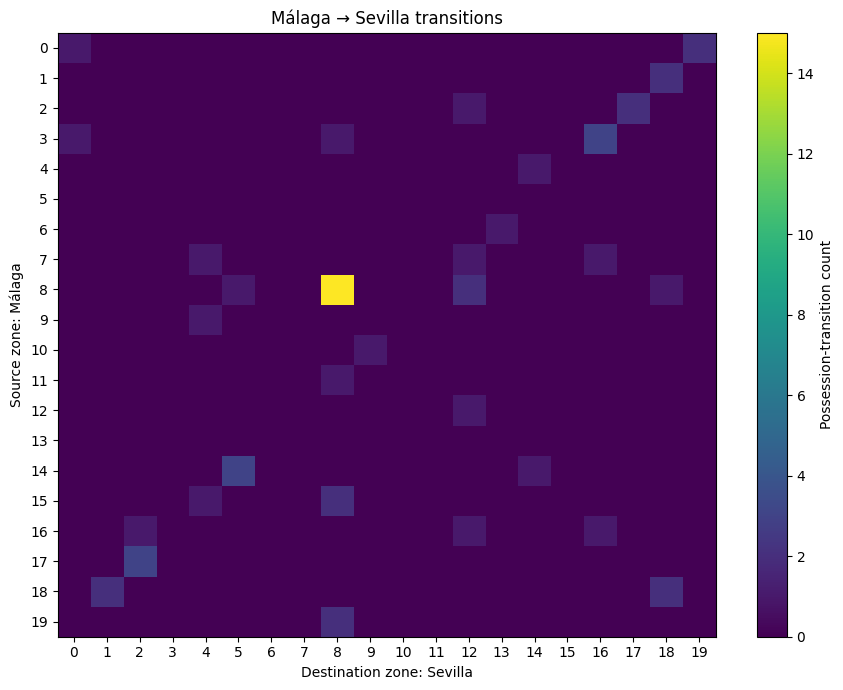

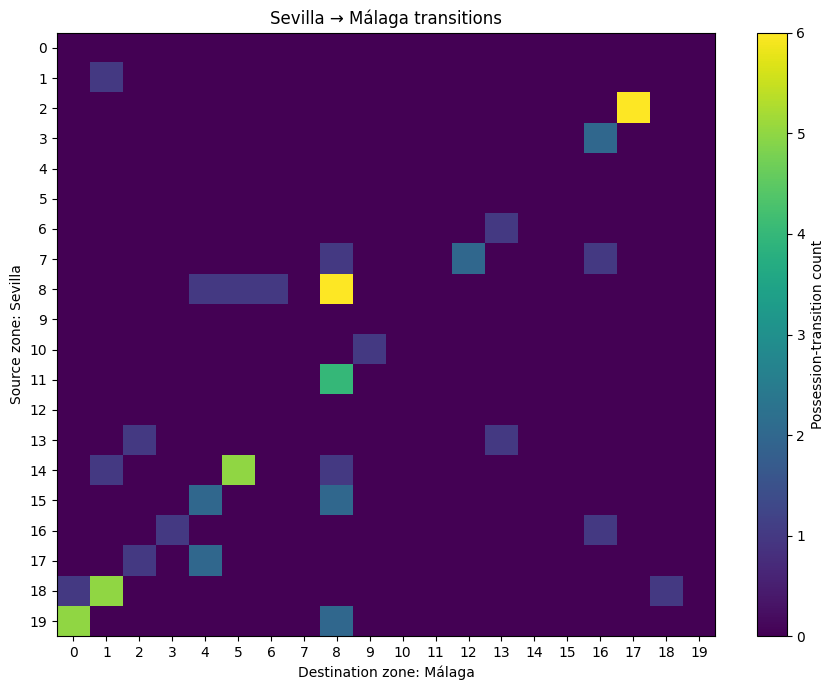

In [73]:
# -------------------------------------------------------------------------
# INTER-LAYER TRANSITION HEATMAPS
# -------------------------------------------------------------------------

plt.figure(figsize=(9, 7))
plt.imshow(
    home_to_away_adjacency,
    aspect="auto",
)
plt.colorbar(
    label="Possession-transition count"
)
plt.xlabel(
    f"Destination zone: {SAMPLE_AWAY_TEAM}"
)
plt.ylabel(
    f"Source zone: {SAMPLE_HOME_TEAM}"
)
plt.title(
    f"{SAMPLE_HOME_TEAM} → "
    f"{SAMPLE_AWAY_TEAM} transitions"
)
plt.xticks(
    range(N_ZONES),
    range(N_ZONES),
)
plt.yticks(
    range(N_ZONES),
    range(N_ZONES),
)
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 7))
plt.imshow(
    away_to_home_adjacency,
    aspect="auto",
)
plt.colorbar(
    label="Possession-transition count"
)
plt.xlabel(
    f"Destination zone: {SAMPLE_HOME_TEAM}"
)
plt.ylabel(
    f"Source zone: {SAMPLE_AWAY_TEAM}"
)
plt.title(
    f"{SAMPLE_AWAY_TEAM} → "
    f"{SAMPLE_HOME_TEAM} transitions"
)
plt.xticks(
    range(N_ZONES),
    range(N_ZONES),
)
plt.yticks(
    range(N_ZONES),
    range(N_ZONES),
)
plt.tight_layout()
plt.show()

In [74]:
# -------------------------------------------------------------------------
# SAMPLE 40 x 40 SUPRA-ADJACENCY MATRIX
# -------------------------------------------------------------------------

assert home_adjacency.shape == (
    N_ZONES,
    N_ZONES,
)

assert away_adjacency.shape == (
    N_ZONES,
    N_ZONES,
)

supra_adjacency = np.block(
    [
        [
            home_adjacency,
            home_to_away_adjacency,
        ],
        [
            away_to_home_adjacency,
            away_adjacency,
        ],
    ]
)

assert supra_adjacency.shape == (
    2 * N_ZONES,
    2 * N_ZONES,
)

expected_total_weight = int(
    home_adjacency.sum()
    + away_adjacency.sum()
    + home_to_away_adjacency.sum()
    + away_to_home_adjacency.sum()
)

assert (
    int(supra_adjacency.sum())
    == expected_total_weight
)

expected_active_edges = int(
    np.count_nonzero(home_adjacency)
    + np.count_nonzero(away_adjacency)
    + np.count_nonzero(
        home_to_away_adjacency
    )
    + np.count_nonzero(
        away_to_home_adjacency
    )
)

assert (
    np.count_nonzero(supra_adjacency)
    == expected_active_edges
)

print("Supra-adjacency matrix constructed.")
print(f"Shape       : {supra_adjacency.shape}")
print(
    f"Total weight: "
    f"{supra_adjacency.sum():,}"
)
print(
    f"Active edges: "
    f"{np.count_nonzero(supra_adjacency):,}"
)

Supra-adjacency matrix constructed.
Shape       : (40, 40)
Total weight: 692
Active edges: 303


In [75]:
# -------------------------------------------------------------------------
# MULTILAYER NODE LABELS
# -------------------------------------------------------------------------

home_layer_labels = [
    f"H_Z{zone_id:02d}"
    for zone_id in range(N_ZONES)
]

away_layer_labels = [
    f"A_Z{zone_id:02d}"
    for zone_id in range(N_ZONES)
]

supra_node_labels = (
    home_layer_labels
    + away_layer_labels
)

assert len(supra_node_labels) == (
    2 * N_ZONES
)

assert len(set(supra_node_labels)) == (
    2 * N_ZONES
)

supra_adjacency_df = pd.DataFrame(
    supra_adjacency,
    index=supra_node_labels,
    columns=supra_node_labels,
)

display(supra_adjacency_df)

,H_Z00,H_Z01,H_Z02,H_Z03,H_Z04,H_Z05,H_Z06,H_Z07,H_Z08,H_Z09,H_Z10,H_Z11,H_Z12,H_Z13,H_Z14,H_Z15,H_Z16,H_Z17,H_Z18,H_Z19,A_Z00,A_Z01,A_Z02,A_Z03,A_Z04,A_Z05,A_Z06,A_Z07,A_Z08,A_Z09,A_Z10,A_Z11,A_Z12,A_Z13,A_Z14,A_Z15,A_Z16,A_Z17,A_Z18,A_Z19
H_Z00,1,3,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
H_Z01,1,8,2,0,2,2,0,0,2,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
H_Z02,0,4,13,2,0,2,8,2,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,2,0,0
H_Z03,0,0,0,6,0,0,1,2,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,3,0,0,0
H_Z04,0,0,1,0,3,1,1,0,0,1,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
H_Z05,1,3,0,0,1,4,1,0,0,5,1,0,0,4,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
H_Z06,0,1,1,1,0,1,10,1,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
H_Z07,0,0,1,2,0,0,2,6,0,0,0,2,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0
H_Z08,0,0,2,0,2,0,0,0,0,3,0,0,0,2,1,0,2,2,3,0,0,0,0,0,0,1,0,0,15,0,0,0,2,0,0,0,0,0,1,0
H_Z09,0,5,5,0,0,3,0,0,0,5,1,0,0,3,1,0,0,1,2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [76]:
# -------------------------------------------------------------------------
# BLOCK-STRUCTURE VALIDATION
# -------------------------------------------------------------------------

assert np.array_equal(
    supra_adjacency[
        :N_ZONES,
        :N_ZONES,
    ],
    home_adjacency,
)

assert np.array_equal(
    supra_adjacency[
        :N_ZONES,
        N_ZONES:,
    ],
    home_to_away_adjacency,
)

assert np.array_equal(
    supra_adjacency[
        N_ZONES:,
        :N_ZONES,
    ],
    away_to_home_adjacency,
)

assert np.array_equal(
    supra_adjacency[
        N_ZONES:,
        N_ZONES:,
    ],
    away_adjacency,
)

print(
    "Supra-adjacency block validation passed."
)

Supra-adjacency block validation passed.


In [77]:
# -------------------------------------------------------------------------
# CREATE SAMPLE MULTILAYER DIRECTED GRAPH
# -------------------------------------------------------------------------

multilayer_graph = nx.from_numpy_array(
    supra_adjacency,
    create_using=nx.DiGraph,
)

node_mapping = {
    node_index: supra_node_labels[
        node_index
    ]
    for node_index in range(
        2 * N_ZONES
    )
}

multilayer_graph = nx.relabel_nodes(
    multilayer_graph,
    node_mapping,
)

zone_reference_indexed_df = (
    zone_reference_df
    .set_index("zone_id")
)

for zone_id in range(N_ZONES):
    zone_row = (
        zone_reference_indexed_df
        .loc[zone_id]
    )

    home_node = f"H_Z{zone_id:02d}"
    away_node = f"A_Z{zone_id:02d}"

    shared_zone_attributes = {
        "zone_id": int(zone_id),
        "x_bin": int(
            zone_row["x_bin"]
        ),
        "y_bin": int(
            zone_row["y_bin"]
        ),
        "x_center": float(
            zone_row["x_center"]
        ),
        "y_center": float(
            zone_row["y_center"]
        ),
    }

    multilayer_graph.nodes[
        home_node
    ].update(
        {
            **shared_zone_attributes,
            "layer": "home",
            "team": SAMPLE_HOME_TEAM,
        }
    )

    multilayer_graph.nodes[
        away_node
    ].update(
        {
            **shared_zone_attributes,
            "layer": "away",
            "team": SAMPLE_AWAY_TEAM,
        }
    )

assert (
    multilayer_graph.number_of_nodes()
    == 2 * N_ZONES
)

assert (
    multilayer_graph.number_of_edges()
    == np.count_nonzero(
        supra_adjacency
    )
)

total_graph_weight = sum(
    edge_attributes["weight"]
    for _, _, edge_attributes
    in multilayer_graph.edges(data=True)
)

assert np.isclose(
    total_graph_weight,
    supra_adjacency.sum(),
)

print("Sample multilayer graph created.")
print(
    f"Nodes: "
    f"{multilayer_graph.number_of_nodes():,}"
)
print(
    f"Edges: "
    f"{multilayer_graph.number_of_edges():,}"
)
print(
    f"Total edge weight: "
    f"{total_graph_weight:,.0f}"
)

Sample multilayer graph created.
Nodes: 40
Edges: 303
Total edge weight: 692


In [78]:
# -------------------------------------------------------------------------
# MULTILAYER EDGE-TYPE VALIDATION
# -------------------------------------------------------------------------

edge_type_counts = {
    "home_intralayer": 0,
    "away_intralayer": 0,
    "home_to_away": 0,
    "away_to_home": 0,
}

edge_type_weights = {
    "home_intralayer": 0.0,
    "away_intralayer": 0.0,
    "home_to_away": 0.0,
    "away_to_home": 0.0,
}

for (
    source_node,
    target_node,
    edge_attributes,
) in multilayer_graph.edges(data=True):

    source_layer = (
        multilayer_graph.nodes[
            source_node
        ]["layer"]
    )

    target_layer = (
        multilayer_graph.nodes[
            target_node
        ]["layer"]
    )

    edge_weight = float(
        edge_attributes["weight"]
    )

    if (
        source_layer == "home"
        and target_layer == "home"
    ):
        edge_type = "home_intralayer"

    elif (
        source_layer == "away"
        and target_layer == "away"
    ):
        edge_type = "away_intralayer"

    elif (
        source_layer == "home"
        and target_layer == "away"
    ):
        edge_type = "home_to_away"

    elif (
        source_layer == "away"
        and target_layer == "home"
    ):
        edge_type = "away_to_home"

    else:
        raise ValueError(
            "Unexpected multilayer edge type."
        )

    edge_type_counts[edge_type] += 1
    edge_type_weights[edge_type] += (
        edge_weight
    )

edge_type_summary_df = pd.DataFrame(
    [
        {
            "edge_type": edge_type,
            "active_edges": (
                edge_type_counts[
                    edge_type
                ]
            ),
            "total_weight": (
                edge_type_weights[
                    edge_type
                ]
            ),
        }
        for edge_type in edge_type_counts
    ]
)

display(edge_type_summary_df)

assert (
    edge_type_counts[
        "home_intralayer"
    ]
    == np.count_nonzero(
        home_adjacency
    )
)

assert (
    edge_type_counts[
        "away_intralayer"
    ]
    == np.count_nonzero(
        away_adjacency
    )
)

assert (
    edge_type_counts[
        "home_to_away"
    ]
    == np.count_nonzero(
        home_to_away_adjacency
    )
)

assert (
    edge_type_counts[
        "away_to_home"
    ]
    == np.count_nonzero(
        away_to_home_adjacency
    )
)

assert np.isclose(
    edge_type_weights[
        "home_intralayer"
    ],
    home_adjacency.sum(),
)

assert np.isclose(
    edge_type_weights[
        "away_intralayer"
    ],
    away_adjacency.sum(),
)

assert np.isclose(
    edge_type_weights[
        "home_to_away"
    ],
    home_to_away_adjacency.sum(),
)

assert np.isclose(
    edge_type_weights[
        "away_to_home"
    ],
    away_to_home_adjacency.sum(),
)

assert (
    edge_type_summary_df[
        "active_edges"
    ].sum()
    == multilayer_graph.number_of_edges()
)

assert np.isclose(
    edge_type_summary_df[
        "total_weight"
    ].sum(),
    supra_adjacency.sum(),
)

print(
    "Multilayer edge-type validation passed."
)

,edge_type,active_edges,total_weight
0,home_intralayer,123,331.0
1,away_intralayer,119,241.0
2,home_to_away,32,60.0
3,away_to_home,29,60.0


Multilayer edge-type validation passed.


## Paper-derived multilayer metrics

The validated \(40 \times 40\) supra-adjacency matrix now supports
the calculation of the paper-derived network measures.

### Eigenvector centrality

For an adjacency matrix \(A\), eigenvector centrality is obtained from:

\[
A x = \lambda x
\]

where \(x\) is the eigenvector associated with the largest eigenvalue.

The implementation uses the right eigenvector, matching the equation
stated in the paper. The resulting non-negative vector is normalized
to sum to one. Accumulated team centrality is calculated by summing
the 20 centrality values belonging to each layer.

### Leakage

For team \(i\) and zone \(j\):

\[
L_j^i =
\frac{
    P_{\mathrm{out},j}^{*i}
}{
    P_{\mathrm{in},j}^{i}
}
\]

The numerator is the number of possessions lost from the selected
team's zone to the rival layer.

The denominator is total incoming activity at that zone:

- completed passes arriving from the same team layer;
- possession recoveries arriving from the rival layer.

### Recovery

For team \(i\) and zone \(j\):

\[
R_j^i =
\frac{
    P_{\mathrm{in},j}^{*i}
}{
    P_{\mathrm{in},j}^{i}
}
\]

The numerator is the number of possession transitions arriving from
the rival layer.

### Switching factor

The switching factor compares possession exchanges with the number
of completed passes arriving at each zone:

\[
\langle S \rangle_i =
\frac{1}{2}
\sum_j
\frac{
    P_{\mathrm{in},j}^{*i}
    +
    P_{\mathrm{out},j}^{*i}
}{
    \mathrm{Passes}_j^i
}
\]

Zones with zero intralayer pass in-degree have an undefined
zone-specific switching ratio. They are retained as missing values
and excluded from the finite sum, while their count is reported.

All measures calculated here describe the completed sample match.
They must later be lagged or historically aggregated before being
used as pre-match features.

In [79]:
# -------------------------------------------------------------------------
# DOMINANT RIGHT-EIGENVECTOR CENTRALITY
# -------------------------------------------------------------------------

def dominant_right_eigenvector_centrality(
    adjacency_matrix,
    normalization="sum",
    tolerance=1e-8,
):
    """
    Calculate dominant right-eigenvector centrality.

    The function solves:

        A x = lambda x

    matching the orientation stated in the paper.

    Parameters
    ----------
    adjacency_matrix : array-like
        Square, non-negative adjacency matrix where rows are
        source nodes and columns are destination nodes.

    normalization : {"sum", "l2"}
        Normalization applied to the non-negative centrality vector.

    tolerance : float
        Maximum accepted residual for A x = lambda x.

    Returns
    -------
    centrality_vector : numpy.ndarray
        Non-negative normalized centrality values.

    dominant_eigenvalue : float
        Largest real eigenvalue.

    residual : float
        Maximum absolute eigen-equation residual.
    """

    matrix = np.asarray(
        adjacency_matrix,
        dtype=np.float64,
    )

    if matrix.ndim != 2:
        raise ValueError(
            "The adjacency matrix must be two-dimensional."
        )

    if matrix.shape[0] != matrix.shape[1]:
        raise ValueError(
            "The adjacency matrix must be square."
        )

    if not np.isfinite(matrix).all():
        raise ValueError(
            "The adjacency matrix contains non-finite values."
        )

    if (matrix < 0).any():
        raise ValueError(
            "Eigenvector centrality requires non-negative weights."
        )

    if np.isclose(matrix.sum(), 0.0):
        raise ValueError(
            "Eigenvector centrality is undefined for an empty network."
        )

    eigenvalues, eigenvectors = np.linalg.eig(matrix)

    dominant_index = int(
        np.argmax(eigenvalues.real)
    )

    dominant_eigenvalue_complex = (
        eigenvalues[dominant_index]
    )

    dominant_vector_complex = (
        eigenvectors[:, dominant_index]
    )

    if abs(dominant_eigenvalue_complex.imag) > tolerance:
        raise ValueError(
            "The dominant eigenvalue has a non-negligible "
            "imaginary component."
        )

    if np.max(
        np.abs(dominant_vector_complex.imag)
    ) > tolerance:
        raise ValueError(
            "The dominant eigenvector has a non-negligible "
            "imaginary component."
        )

    dominant_eigenvalue = float(
        dominant_eigenvalue_complex.real
    )

    centrality_vector = (
        dominant_vector_complex.real
    )

    # An eigenvector and its negative are equivalent.
    # Convert to a consistent non-negative orientation.
    if centrality_vector.sum() < 0:
        centrality_vector = -centrality_vector

    # Numerical noise can produce tiny negative values.
    centrality_vector[
        np.abs(centrality_vector) < tolerance
    ] = 0.0

    if (centrality_vector < -tolerance).any():
        # For a non-negative matrix the Perron vector should be
        # non-negative. Absolute values provide a stable representation
        # when numerical eigensolvers return an equivalent signed basis.
        centrality_vector = np.abs(
            centrality_vector
        )
    else:
        centrality_vector = np.clip(
            centrality_vector,
            0.0,
            None,
        )

    if normalization == "sum":
        normalizer = centrality_vector.sum()

    elif normalization == "l2":
        normalizer = np.linalg.norm(
            centrality_vector
        )

    else:
        raise ValueError(
            "normalization must be either 'sum' or 'l2'."
        )

    if np.isclose(normalizer, 0.0):
        raise ValueError(
            "The dominant eigenvector cannot be normalized."
        )

    centrality_vector = (
        centrality_vector / normalizer
    )

    residual = float(
        np.max(
            np.abs(
                matrix @ centrality_vector
                - dominant_eigenvalue
                * centrality_vector
            )
        )
    )

    if residual > tolerance:
        raise ValueError(
            "The eigenvector residual exceeds tolerance: "
            f"{residual:.3e}"
        )

    return (
        centrality_vector,
        dominant_eigenvalue,
        residual,
    )

In [80]:
# -------------------------------------------------------------------------
# SAMPLE SUPRA-NETWORK EIGENVECTOR CENTRALITY
# -------------------------------------------------------------------------

(
    sample_supra_centrality,
    sample_dominant_eigenvalue,
    sample_centrality_residual,
) = dominant_right_eigenvector_centrality(
    adjacency_matrix=supra_adjacency,
    normalization="sum",
)

assert len(sample_supra_centrality) == (
    2 * N_ZONES
)

assert np.isclose(
    sample_supra_centrality.sum(),
    1.0,
)

assert (
    sample_supra_centrality >= 0
).all()

sample_node_metrics_df = pd.DataFrame(
    {
        "node_label": supra_node_labels,
        "layer": (
            ["home"] * N_ZONES
            + ["away"] * N_ZONES
        ),
        "team": (
            [SAMPLE_HOME_TEAM] * N_ZONES
            + [SAMPLE_AWAY_TEAM] * N_ZONES
        ),
        "zone_id": (
            list(range(N_ZONES))
            + list(range(N_ZONES))
        ),
        "eigenvector_centrality": (
            sample_supra_centrality
        ),
    }
)

sample_node_metrics_df[
    "eigenvector_centrality_percent"
] = (
    sample_node_metrics_df[
        "eigenvector_centrality"
    ]
    * 100.0
)

print("Supra-network eigenvector centrality calculated.")
print(
    f"Dominant eigenvalue: "
    f"{sample_dominant_eigenvalue:.6f}"
)
print(
    f"Maximum residual   : "
    f"{sample_centrality_residual:.3e}"
)

display(
    sample_node_metrics_df
    .sort_values(
        "eigenvector_centrality",
        ascending=False,
    )
    .head(15)
)

Supra-network eigenvector centrality calculated.
Dominant eigenvalue: 23.255493
Maximum residual   : 6.439e-15


,node_label,layer,team,zone_id,eigenvector_centrality,eigenvector_centrality_percent
17,H_Z17,home,Málaga,17,0.092956,9.295609
18,H_Z18,home,Málaga,18,0.088611,8.861121
8,H_Z08,home,Málaga,8,0.069620,6.962027
9,H_Z09,home,Málaga,9,0.059949,5.994927
22,A_Z02,away,Sevilla,2,0.058597,5.859749
13,H_Z13,home,Málaga,13,0.057996,5.799560
14,H_Z14,home,Málaga,14,0.048066,4.806594
2,H_Z02,home,Málaga,2,0.046577,4.657748
5,H_Z05,home,Málaga,5,0.042363,4.236254
28,A_Z08,away,Sevilla,8,0.042160,4.215983


In [81]:
# -------------------------------------------------------------------------
# ACCUMULATED TEAM EIGENVECTOR CENTRALITY
# -------------------------------------------------------------------------

sample_team_centrality_df = (
    sample_node_metrics_df
    .groupby(
        [
            "layer",
            "team",
        ],
        as_index=False,
    )
    .agg(
        accumulated_eigenvector_centrality=(
            "eigenvector_centrality",
            "sum",
        ),
        maximum_zone_centrality=(
            "eigenvector_centrality",
            "max",
        ),
        mean_zone_centrality=(
            "eigenvector_centrality",
            "mean",
        ),
    )
)

sample_team_centrality_df[
    "accumulated_eigenvector_centrality_percent"
] = (
    sample_team_centrality_df[
        "accumulated_eigenvector_centrality"
    ]
    * 100.0
)

assert np.isclose(
    sample_team_centrality_df[
        "accumulated_eigenvector_centrality"
    ].sum(),
    1.0,
)

print("Accumulated team centrality calculated.")

display(
    sample_team_centrality_df[
        [
            "layer",
            "team",
            "accumulated_eigenvector_centrality",
            "accumulated_eigenvector_centrality_percent",
            "maximum_zone_centrality",
            "mean_zone_centrality",
        ]
    ]
)

Accumulated team centrality calculated.


,layer,team,accumulated_eigenvector_centrality,accumulated_eigenvector_centrality_percent,maximum_zone_centrality,mean_zone_centrality
0,away,Sevilla,0.322226,32.222605,0.058597,0.016111
1,home,Málaga,0.677774,67.777395,0.092956,0.033889


In [82]:
# -------------------------------------------------------------------------
# SAFE ZONE-WISE DIVISION
# -------------------------------------------------------------------------

def safe_zone_ratio(
    numerator,
    denominator,
):
    """
    Divide two equal-length zone vectors.

    A missing value is returned where the denominator is zero.
    """

    numerator_array = np.asarray(
        numerator,
        dtype=np.float64,
    )

    denominator_array = np.asarray(
        denominator,
        dtype=np.float64,
    )

    if (
        numerator_array.shape
        != denominator_array.shape
    ):
        raise ValueError(
            "Numerator and denominator shapes do not match."
        )

    ratio = np.full(
        numerator_array.shape,
        np.nan,
        dtype=np.float64,
    )

    valid_denominator_mask = (
        denominator_array > 0
    )

    ratio[valid_denominator_mask] = (
        numerator_array[
            valid_denominator_mask
        ]
        / denominator_array[
            valid_denominator_mask
        ]
    )

    return ratio

In [83]:
# -------------------------------------------------------------------------
# ZONE-LEVEL LEAKAGE, RECOVERY AND SWITCHING
# -------------------------------------------------------------------------

def calculate_team_multilayer_zone_metrics(
    intralayer_adjacency,
    outgoing_interlayer_adjacency,
    incoming_interlayer_adjacency,
    team_name,
    layer_name,
):
    """
    Calculate paper-derived zone metrics for one team.

    Matrix orientation
    ------------------
    intralayer_adjacency:
        selected team source zones → selected team destination zones

    outgoing_interlayer_adjacency:
        selected team source zones → rival destination zones

    incoming_interlayer_adjacency:
        rival source zones → selected team destination zones
    """

    intralayer_matrix = np.asarray(
        intralayer_adjacency,
        dtype=np.float64,
    )

    outgoing_matrix = np.asarray(
        outgoing_interlayer_adjacency,
        dtype=np.float64,
    )

    incoming_matrix = np.asarray(
        incoming_interlayer_adjacency,
        dtype=np.float64,
    )

    expected_shape = (
        N_ZONES,
        N_ZONES,
    )

    for matrix_name, matrix in {
        "intralayer": intralayer_matrix,
        "outgoing_interlayer": outgoing_matrix,
        "incoming_interlayer": incoming_matrix,
    }.items():
        if matrix.shape != expected_shape:
            raise ValueError(
                f"{matrix_name} matrix has shape "
                f"{matrix.shape}; expected {expected_shape}."
            )

        if (matrix < 0).any():
            raise ValueError(
                f"{matrix_name} contains negative weights."
            )

    # Passes arriving at each zone in the selected layer.
    intralayer_pass_in_degree = (
        intralayer_matrix.sum(axis=0)
    )

    # Passes leaving each selected-team zone.
    intralayer_pass_out_degree = (
        intralayer_matrix.sum(axis=1)
    )

    # Possession losses from each selected-team zone.
    interlayer_out_degree = (
        outgoing_matrix.sum(axis=1)
    )

    # Possession recoveries arriving at each selected-team zone.
    interlayer_in_degree = (
        incoming_matrix.sum(axis=0)
    )

    # Paper denominator for leakage and recovery.
    total_in_degree = (
        intralayer_pass_in_degree
        + interlayer_in_degree
    )

    leakage = safe_zone_ratio(
        numerator=interlayer_out_degree,
        denominator=total_in_degree,
    )

    recovery = safe_zone_ratio(
        numerator=interlayer_in_degree,
        denominator=total_in_degree,
    )

    # Literal zone-wise component of the paper's switching formula.
    switching_zone_ratio = safe_zone_ratio(
        numerator=(
            interlayer_in_degree
            + interlayer_out_degree
        ),
        denominator=intralayer_pass_in_degree,
    )

    zone_metrics_df = pd.DataFrame(
        {
            "team": team_name,
            "layer": layer_name,
            "zone_id": np.arange(
                N_ZONES,
                dtype=int,
            ),
            "pass_in_degree": (
                intralayer_pass_in_degree
            ),
            "pass_out_degree": (
                intralayer_pass_out_degree
            ),
            "interlayer_in_degree": (
                interlayer_in_degree
            ),
            "interlayer_out_degree": (
                interlayer_out_degree
            ),
            "total_in_degree": (
                total_in_degree
            ),
            "leakage": leakage,
            "recovery": recovery,
            "switching_zone_ratio": (
                switching_zone_ratio
            ),
        }
    )

    zone_metrics_df["leakage_percent"] = (
        zone_metrics_df["leakage"]
        * 100.0
    )

    zone_metrics_df["recovery_percent"] = (
        zone_metrics_df["recovery"]
        * 100.0
    )

    zone_metrics_df[
        "switching_zone_ratio_percent"
    ] = (
        zone_metrics_df[
            "switching_zone_ratio"
        ]
        * 100.0
    )

    # Paper-literal switching factor:
    # one half of the finite zone-ratio sum.
    switching_factor = (
        0.5
        * np.nansum(
            switching_zone_ratio
        )
    )

    finite_switching_zone_count = int(
        np.isfinite(
            switching_zone_ratio
        ).sum()
    )

    undefined_switching_zone_count = int(
        np.isnan(
            switching_zone_ratio
        ).sum()
    )

    diagnostics = {
        "team": team_name,
        "layer": layer_name,
        "completed_passes": int(
            intralayer_matrix.sum()
        ),
        "possession_losses": int(
            outgoing_matrix.sum()
        ),
        "possession_recoveries": int(
            incoming_matrix.sum()
        ),
        "finite_switching_zones": (
            finite_switching_zone_count
        ),
        "undefined_switching_zones": (
            undefined_switching_zone_count
        ),
        "switching_factor": float(
            switching_factor
        ),
        "switching_factor_percent": float(
            switching_factor * 100.0
        ),
    }

    return zone_metrics_df, diagnostics

In [84]:
# -------------------------------------------------------------------------
# SAMPLE HOME AND AWAY ZONE METRICS
# -------------------------------------------------------------------------

(
    sample_home_zone_metrics_df,
    sample_home_metric_diagnostics,
) = calculate_team_multilayer_zone_metrics(
    intralayer_adjacency=home_adjacency,
    outgoing_interlayer_adjacency=(
        home_to_away_adjacency
    ),
    incoming_interlayer_adjacency=(
        away_to_home_adjacency
    ),
    team_name=SAMPLE_HOME_TEAM,
    layer_name="home",
)

(
    sample_away_zone_metrics_df,
    sample_away_metric_diagnostics,
) = calculate_team_multilayer_zone_metrics(
    intralayer_adjacency=away_adjacency,
    outgoing_interlayer_adjacency=(
        away_to_home_adjacency
    ),
    incoming_interlayer_adjacency=(
        home_to_away_adjacency
    ),
    team_name=SAMPLE_AWAY_TEAM,
    layer_name="away",
)

sample_zone_metrics_df = pd.concat(
    [
        sample_home_zone_metrics_df,
        sample_away_zone_metrics_df,
    ],
    ignore_index=True,
)

assert len(sample_zone_metrics_df) == (
    2 * N_ZONES
)

assert (
    sample_home_zone_metrics_df[
        "interlayer_out_degree"
    ].sum()
    == home_to_away_adjacency.sum()
)

assert (
    sample_home_zone_metrics_df[
        "interlayer_in_degree"
    ].sum()
    == away_to_home_adjacency.sum()
)

assert (
    sample_away_zone_metrics_df[
        "interlayer_out_degree"
    ].sum()
    == away_to_home_adjacency.sum()
)

assert (
    sample_away_zone_metrics_df[
        "interlayer_in_degree"
    ].sum()
    == home_to_away_adjacency.sum()
)

print("Zone-level multilayer metrics calculated.")

display(
    sample_zone_metrics_df[
        [
            "team",
            "layer",
            "zone_id",
            "pass_in_degree",
            "interlayer_in_degree",
            "interlayer_out_degree",
            "total_in_degree",
            "leakage_percent",
            "recovery_percent",
            "switching_zone_ratio_percent",
        ]
    ]
)

Zone-level multilayer metrics calculated.


,team,layer,zone_id,pass_in_degree,interlayer_in_degree,interlayer_out_degree,total_in_degree,leakage_percent,recovery_percent,switching_zone_ratio_percent
0,Málaga,home,0,3.0,6.0,3.0,9.0,33.333333,66.666667,300.000000
1,Málaga,home,1,25.0,7.0,2.0,32.0,6.250000,21.875000,36.000000
2,Málaga,home,2,26.0,2.0,3.0,28.0,10.714286,7.142857,19.230769
3,Málaga,home,3,11.0,1.0,5.0,12.0,41.666667,8.333333,54.545455
4,Málaga,home,4,9.0,5.0,1.0,14.0,7.142857,35.714286,66.666667
5,Málaga,home,5,18.0,6.0,0.0,24.0,0.000000,25.000000,33.333333
6,Málaga,home,6,27.0,1.0,1.0,28.0,3.571429,3.571429,7.407407
7,Málaga,home,7,19.0,0.0,3.0,19.0,15.789474,0.000000,15.789474
8,Málaga,home,8,4.0,16.0,19.0,20.0,95.000000,80.000000,875.000000
9,Málaga,home,9,28.0,1.0,1.0,29.0,3.448276,3.448276,7.142857


In [85]:
# -------------------------------------------------------------------------
# LEAKAGE AND RECOVERY VALIDATION
# -------------------------------------------------------------------------

for (
    metric_name,
    metric_series,
) in [
    (
        "home leakage",
        sample_home_zone_metrics_df[
            "leakage"
        ],
    ),
    (
        "home recovery",
        sample_home_zone_metrics_df[
            "recovery"
        ],
    ),
    (
        "away leakage",
        sample_away_zone_metrics_df[
            "leakage"
        ],
    ),
    (
        "away recovery",
        sample_away_zone_metrics_df[
            "recovery"
        ],
    ),
]:
    finite_values = metric_series.dropna()

    assert (
        finite_values >= 0
    ).all(), (
        f"Negative values detected in {metric_name}."
    )

    # Recovery cannot exceed one because its numerator is a
    # component of total incoming degree.
    if "recovery" in metric_name:
        assert (
            finite_values <= 1
        ).all(), (
            f"Values greater than one detected in "
            f"{metric_name}."
        )

# Leakage can exceed one under the paper's definition because
# losses from a zone are divided by arrivals into that zone.
# It must therefore be non-negative, but is not artificially capped.

print("Leakage and recovery validation passed.")

print(
    "Home zones with undefined leakage: "
    f"{sample_home_zone_metrics_df['leakage'].isna().sum()}"
)
print(
    "Away zones with undefined leakage: "
    f"{sample_away_zone_metrics_df['leakage'].isna().sum()}"
)
print(
    "Home zones with undefined recovery: "
    f"{sample_home_zone_metrics_df['recovery'].isna().sum()}"
)
print(
    "Away zones with undefined recovery: "
    f"{sample_away_zone_metrics_df['recovery'].isna().sum()}"
)

Leakage and recovery validation passed.
Home zones with undefined leakage: 0
Away zones with undefined leakage: 0
Home zones with undefined recovery: 0
Away zones with undefined recovery: 0


In [86]:
# -------------------------------------------------------------------------
# SAMPLE TEAM-LEVEL PAPER METRICS
# -------------------------------------------------------------------------

sample_team_metric_diagnostics_df = pd.DataFrame(
    [
        sample_home_metric_diagnostics,
        sample_away_metric_diagnostics,
    ]
)

# Team-level leakage and recovery are stored as means over
# zones with a defined denominator.
team_zone_summary_df = (
    sample_zone_metrics_df
    .groupby(
        [
            "layer",
            "team",
        ],
        as_index=False,
    )
    .agg(
        mean_zone_leakage=(
            "leakage",
            "mean",
        ),
        median_zone_leakage=(
            "leakage",
            "median",
        ),
        mean_zone_recovery=(
            "recovery",
            "mean",
        ),
        median_zone_recovery=(
            "recovery",
            "median",
        ),
        defined_leakage_zones=(
            "leakage",
            "count",
        ),
        defined_recovery_zones=(
            "recovery",
            "count",
        ),
    )
)

sample_team_metrics_df = (
    sample_team_centrality_df
    .merge(
        team_zone_summary_df,
        on=[
            "layer",
            "team",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        sample_team_metric_diagnostics_df,
        on=[
            "layer",
            "team",
        ],
        how="left",
        validate="one_to_one",
    )
)

sample_team_metrics_df[
    "mean_zone_leakage_percent"
] = (
    sample_team_metrics_df[
        "mean_zone_leakage"
    ]
    * 100.0
)

sample_team_metrics_df[
    "mean_zone_recovery_percent"
] = (
    sample_team_metrics_df[
        "mean_zone_recovery"
    ]
    * 100.0
)

sample_team_metrics_df.insert(
    0,
    "match_id",
    SAMPLE_MATCH_ID,
)

display(
    sample_team_metrics_df[
        [
            "match_id",
            "layer",
            "team",
            "completed_passes",
            "possession_losses",
            "possession_recoveries",
            "accumulated_eigenvector_centrality_percent",
            "mean_zone_leakage_percent",
            "mean_zone_recovery_percent",
            "switching_factor_percent",
            "finite_switching_zones",
            "undefined_switching_zones",
        ]
    ]
)

,match_id,layer,team,completed_passes,possession_losses,possession_recoveries,accumulated_eigenvector_centrality_percent,mean_zone_leakage_percent,mean_zone_recovery_percent,switching_factor_percent,finite_switching_zones,undefined_switching_zones
0,3825562,away,Sevilla,241,60,60,32.222605,39.498953,15.922619,705.051407,20,0
1,3825562,home,Málaga,331,60,60,67.777395,18.955705,18.685883,976.745468,20,0


In [87]:
# -------------------------------------------------------------------------
# COMPLETE SAMPLE NODE-METRIC TABLE
# -------------------------------------------------------------------------

sample_complete_node_metrics_df = (
    sample_zone_metrics_df
    .merge(
        sample_node_metrics_df[
            [
                "layer",
                "team",
                "zone_id",
                "node_label",
                "eigenvector_centrality",
                "eigenvector_centrality_percent",
            ]
        ],
        on=[
            "layer",
            "team",
            "zone_id",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        zone_reference_df,
        on="zone_id",
        how="left",
        validate="many_to_one",
    )
)

sample_complete_node_metrics_df.insert(
    0,
    "match_id",
    SAMPLE_MATCH_ID,
)

assert len(
    sample_complete_node_metrics_df
) == 2 * N_ZONES

assert sample_complete_node_metrics_df[
    "eigenvector_centrality"
].notna().all()

assert np.isclose(
    sample_complete_node_metrics_df[
        "eigenvector_centrality"
    ].sum(),
    1.0,
)

display(
    sample_complete_node_metrics_df[
        [
            "match_id",
            "team",
            "layer",
            "node_label",
            "zone_id",
            "eigenvector_centrality_percent",
            "leakage_percent",
            "recovery_percent",
            "switching_zone_ratio_percent",
            "x_center",
            "y_center",
        ]
    ]
)

,match_id,team,layer,node_label,zone_id,eigenvector_centrality_percent,leakage_percent,recovery_percent,switching_zone_ratio_percent,x_center,y_center
0,3825562,Málaga,home,H_Z00,0,0.897040,33.333333,66.666667,300.000000,15.0,8.0
1,3825562,Málaga,home,H_Z01,1,4.025426,6.250000,21.875000,36.000000,45.0,8.0
2,3825562,Málaga,home,H_Z02,2,4.657748,10.714286,7.142857,19.230769,75.0,8.0
3,3825562,Málaga,home,H_Z03,3,0.617958,41.666667,8.333333,54.545455,105.0,8.0
4,3825562,Málaga,home,H_Z04,4,1.113017,7.142857,35.714286,66.666667,15.0,24.0
5,3825562,Málaga,home,H_Z05,5,4.236254,0.000000,25.000000,33.333333,45.0,24.0
6,3825562,Málaga,home,H_Z06,6,1.889703,3.571429,3.571429,7.407407,75.0,24.0
7,3825562,Málaga,home,H_Z07,7,0.846858,15.789474,0.000000,15.789474,105.0,24.0
8,3825562,Málaga,home,H_Z08,8,6.962027,95.000000,80.000000,875.000000,15.0,40.0
9,3825562,Málaga,home,H_Z09,9,5.994927,3.448276,3.448276,7.142857,45.0,40.0


In [88]:
# -------------------------------------------------------------------------
# MOST IMPORTANT SAMPLE ZONES
# -------------------------------------------------------------------------

sample_top_zones_df = (
    sample_complete_node_metrics_df
    .sort_values(
        [
            "team",
            "eigenvector_centrality",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .groupby(
        "team",
        as_index=False,
        group_keys=False,
    )
    .head(5)
    .reset_index(drop=True)
)

print("Five highest-centrality zones per team:")

display(
    sample_top_zones_df[
        [
            "team",
            "zone_id",
            "x_center",
            "y_center",
            "eigenvector_centrality_percent",
            "pass_in_degree",
            "interlayer_in_degree",
            "interlayer_out_degree",
            "leakage_percent",
            "recovery_percent",
        ]
    ]
)

Five highest-centrality zones per team:


,team,zone_id,x_center,y_center,eigenvector_centrality_percent,pass_in_degree,interlayer_in_degree,interlayer_out_degree,leakage_percent,recovery_percent
0,Málaga,17,45.0,72.0,9.295609,20.0,6.0,3.0,11.538462,23.076923
1,Málaga,18,75.0,72.0,8.861121,34.0,1.0,4.0,11.428571,2.857143
2,Málaga,8,15.0,40.0,6.962027,4.0,16.0,19.0,95.000000,80.000000
3,Málaga,9,45.0,40.0,5.994927,28.0,1.0,1.0,3.448276,3.448276
4,Málaga,13,45.0,56.0,5.799560,26.0,2.0,0.0,0.000000,7.142857
5,Sevilla,2,75.0,8.0,5.859749,18.0,4.0,6.0,27.272727,18.181818
6,Sevilla,8,15.0,40.0,4.215983,12.0,21.0,9.0,27.272727,63.636364
7,Sevilla,14,75.0,56.0,3.021934,18.0,2.0,7.0,35.000000,10.000000
8,Sevilla,18,75.0,72.0,2.731651,20.0,5.0,7.0,28.000000,20.000000
9,Sevilla,1,45.0,8.0,1.732686,27.0,2.0,1.0,3.448276,6.896552


In [89]:
# -------------------------------------------------------------------------
# 4 x 5 ZONE HEATMAP UTILITY
# -------------------------------------------------------------------------

def plot_zone_metric_heatmap(
    zone_metrics_df,
    team_name,
    metric_column,
    title,
):
    """
    Plot one 20-zone metric using the notebook's 5-row × 4-column grid.
    """

    selected_team_df = (
        zone_metrics_df[
            zone_metrics_df["team"]
            == team_name
        ]
        .sort_values("zone_id")
        .copy()
    )

    if len(selected_team_df) != N_ZONES:
        raise ValueError(
            f"Expected {N_ZONES} zones for {team_name}; "
            f"found {len(selected_team_df)}."
        )

    metric_values = (
        selected_team_df[
            metric_column
        ]
        .to_numpy(
            dtype=np.float64
        )
        .reshape(
            GRID_Y_BINS,
            GRID_X_BINS,
        )
    )

    plt.figure(figsize=(8, 7))
    plt.imshow(
        metric_values,
        aspect="auto",
        origin="lower",
    )
    plt.colorbar(
        label=metric_column
    )

    for y_bin in range(
        GRID_Y_BINS
    ):
        for x_bin in range(
            GRID_X_BINS
        ):
            zone_id = (
                y_bin * GRID_X_BINS
                + x_bin
            )

            value = metric_values[
                y_bin,
                x_bin,
            ]

            value_label = (
                "NA"
                if np.isnan(value)
                else f"{value:.1f}"
            )

            plt.text(
                x_bin,
                y_bin,
                f"Z{zone_id}\n{value_label}",
                ha="center",
                va="center",
            )

    plt.xticks(
        range(GRID_X_BINS),
        [
            f"X{x_bin}"
            for x_bin
            in range(GRID_X_BINS)
        ],
    )

    plt.yticks(
        range(GRID_Y_BINS),
        [
            f"Y{y_bin}"
            for y_bin
            in range(GRID_Y_BINS)
        ],
    )

    plt.xlabel("Longitudinal pitch bin")
    plt.ylabel("Lateral pitch bin")
    plt.title(title)
    plt.tight_layout()
    plt.show()

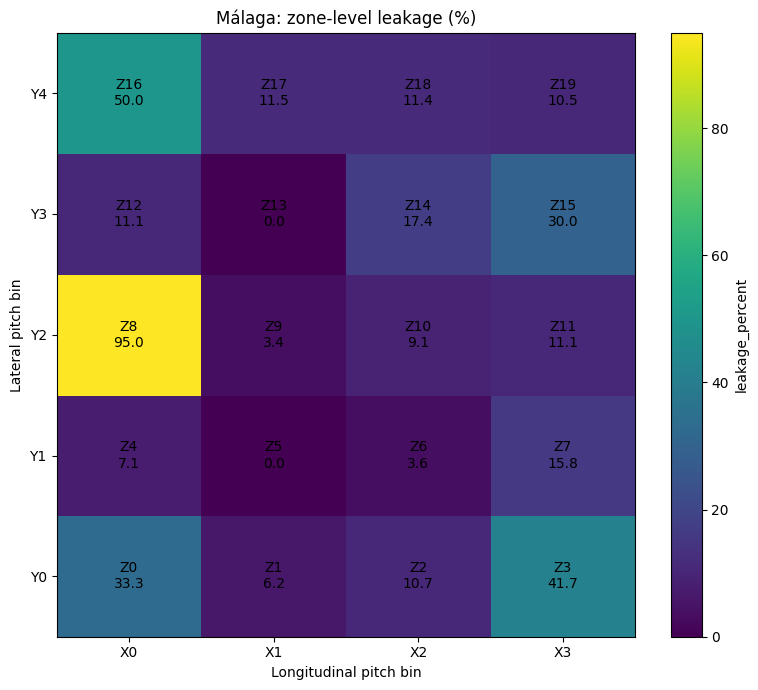

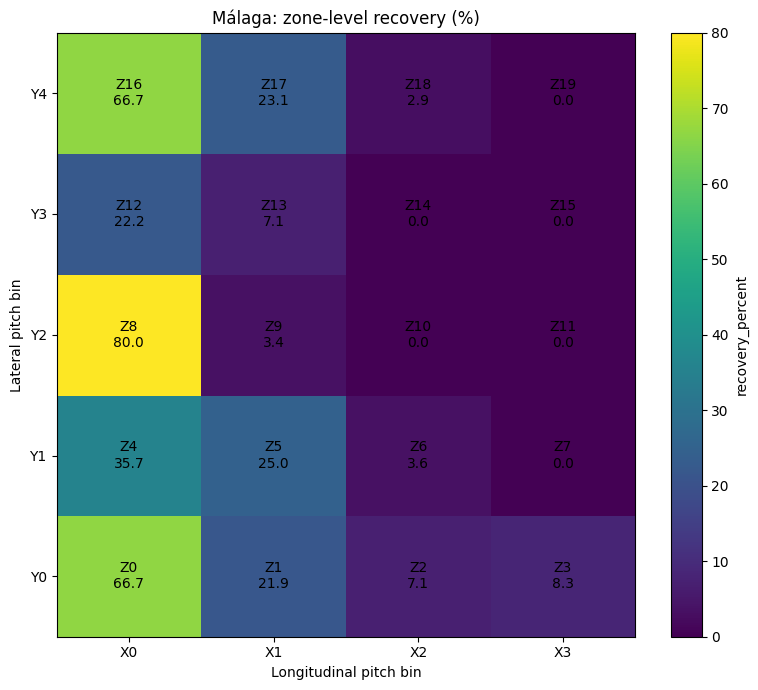

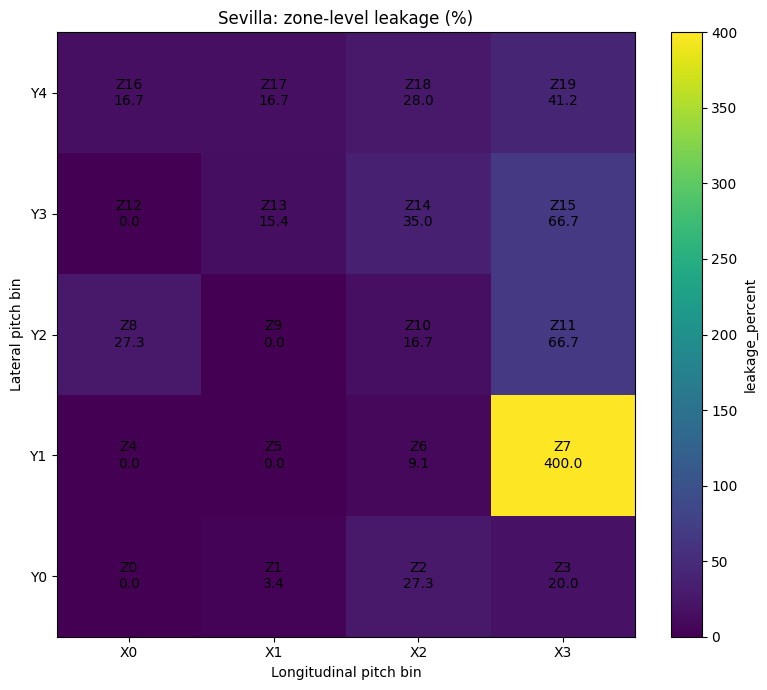

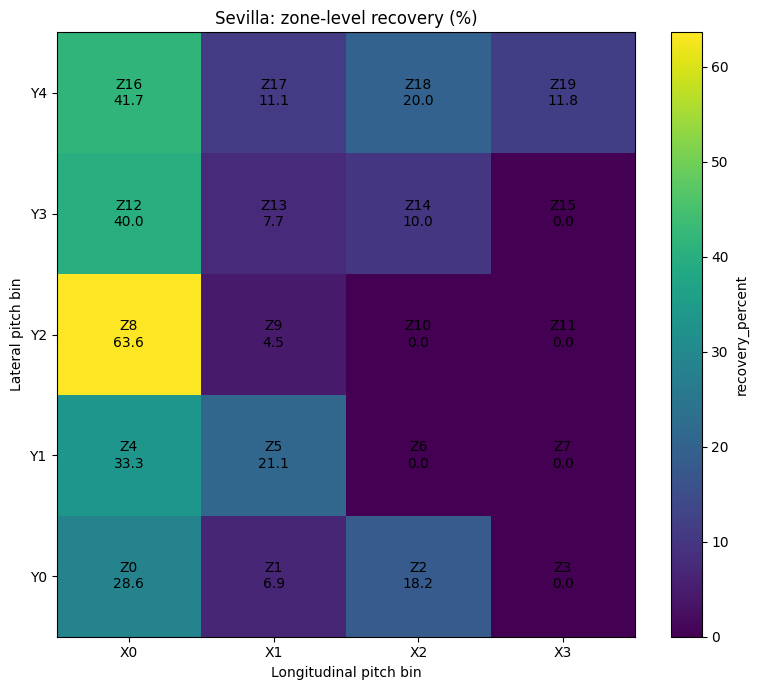

In [90]:
# -------------------------------------------------------------------------
# SAMPLE LEAKAGE AND RECOVERY HEATMAPS
# -------------------------------------------------------------------------

plot_zone_metric_heatmap(
    zone_metrics_df=(
        sample_complete_node_metrics_df
    ),
    team_name=SAMPLE_HOME_TEAM,
    metric_column="leakage_percent",
    title=(
        f"{SAMPLE_HOME_TEAM}: "
        "zone-level leakage (%)"
    ),
)

plot_zone_metric_heatmap(
    zone_metrics_df=(
        sample_complete_node_metrics_df
    ),
    team_name=SAMPLE_HOME_TEAM,
    metric_column="recovery_percent",
    title=(
        f"{SAMPLE_HOME_TEAM}: "
        "zone-level recovery (%)"
    ),
)

plot_zone_metric_heatmap(
    zone_metrics_df=(
        sample_complete_node_metrics_df
    ),
    team_name=SAMPLE_AWAY_TEAM,
    metric_column="leakage_percent",
    title=(
        f"{SAMPLE_AWAY_TEAM}: "
        "zone-level leakage (%)"
    ),
)

plot_zone_metric_heatmap(
    zone_metrics_df=(
        sample_complete_node_metrics_df
    ),
    team_name=SAMPLE_AWAY_TEAM,
    metric_column="recovery_percent",
    title=(
        f"{SAMPLE_AWAY_TEAM}: "
        "zone-level recovery (%)"
    ),
)

In [91]:
# -------------------------------------------------------------------------
# FINAL SAMPLE-MATCH METRIC VALIDATION
# -------------------------------------------------------------------------

assert len(
    sample_team_metrics_df
) == 2

assert set(
    sample_team_metrics_df["team"]
) == {
    SAMPLE_HOME_TEAM,
    SAMPLE_AWAY_TEAM,
}

assert (
    sample_team_metrics_df[
        "completed_passes"
    ].sum()
    == home_adjacency.sum()
    + away_adjacency.sum()
)

assert (
    sample_team_metrics_df[
        "possession_losses"
    ].sum()
    == len(sample_transitions_df)
)

assert (
    sample_team_metrics_df[
        "possession_recoveries"
    ].sum()
    == len(sample_transitions_df)
)

# Every transition is a loss for one team and a recovery for the other.
assert (
    sample_team_metrics_df[
        "possession_losses"
    ].sum()
    == sample_team_metrics_df[
        "possession_recoveries"
    ].sum()
)

assert np.isclose(
    sample_team_metrics_df[
        "accumulated_eigenvector_centrality"
    ].sum(),
    1.0,
)

assert (
    sample_team_metrics_df[
        "switching_factor"
    ] >= 0
).all()

assert (
    sample_complete_node_metrics_df[
        "zone_id"
    ].between(
        0,
        N_ZONES - 1,
    )
).all()

print(
    "All sample-match paper-metric validations passed."
)

print(
    f"Validated match: "
    f"{SAMPLE_HOME_TEAM} vs {SAMPLE_AWAY_TEAM}"
)

print(
    "The sample network now contains validated "
    "centrality, leakage, recovery and switching metrics."
)

All sample-match paper-metric validations passed.
Validated match: Málaga vs Sevilla
The sample network now contains validated centrality, leakage, recovery and switching metrics.


In [92]:
# -------------------------------------------------------------------------
# FULL-SEASON NETWORK OUTPUT PATHS
# -------------------------------------------------------------------------

TEAM_METRICS_OUTPUT_PATH = Path(
    "../data/processed/"
    "multilayer_team_match_metrics_laliga_2015_2016.parquet"
)

ZONE_METRICS_OUTPUT_PATH = Path(
    "../data/processed/"
    "multilayer_team_zone_metrics_laliga_2015_2016.parquet"
)

NETWORK_LOG_OUTPUT_PATH = Path(
    "../data/processed/"
    "multilayer_network_processing_log_laliga_2015_2016.csv"
)

TEAM_METRICS_OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

ZONE_METRICS_OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

NETWORK_LOG_OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

print("Full-season output paths configured.")
print(f"Team metrics: {TEAM_METRICS_OUTPUT_PATH.resolve()}")
print(f"Zone metrics: {ZONE_METRICS_OUTPUT_PATH.resolve()}")
print(f"Process log : {NETWORK_LOG_OUTPUT_PATH.resolve()}")

Full-season output paths configured.
Team metrics: /home/sina/Documents/Arshad/Spring - 2026/Machine Learning/home works/Project/data/processed/multilayer_team_match_metrics_laliga_2015_2016.parquet
Zone metrics: /home/sina/Documents/Arshad/Spring - 2026/Machine Learning/home works/Project/data/processed/multilayer_team_zone_metrics_laliga_2015_2016.parquet
Process log : /home/sina/Documents/Arshad/Spring - 2026/Machine Learning/home works/Project/data/processed/multilayer_network_processing_log_laliga_2015_2016.csv


In [93]:
# -------------------------------------------------------------------------
# PREPARE COMPLETED PASSES FOR ONE MATCH
# -------------------------------------------------------------------------

def prepare_completed_passes(
    match_events_df,
    coordinate_zone_function,
    n_zones=20,
):
    """
    Select completed passes with valid coordinates and assign zones.

    In the StatsBomb flattened representation, a missing pass_outcome
    identifies a completed pass.
    """

    required_columns = {
        "type",
        "team",
        "pass_outcome",
        "location_x",
        "location_y",
        "pass_end_x",
        "pass_end_y",
    }

    missing_columns = (
        required_columns - set(match_events_df.columns)
    )

    if missing_columns:
        raise ValueError(
            "Cannot prepare completed passes. Missing columns: "
            f"{sorted(missing_columns)}"
        )

    passes_df = match_events_df.loc[
        match_events_df["type"].eq("Pass")
    ].copy()

    completed_passes_df = passes_df.loc[
        passes_df["pass_outcome"].isna()
    ].copy()

    coordinate_columns = [
        "location_x",
        "location_y",
        "pass_end_x",
        "pass_end_y",
    ]

    valid_coordinate_mask = (
        completed_passes_df[
            coordinate_columns
        ]
        .notna()
        .all(axis=1)
    )

    missing_coordinate_count = int(
        (~valid_coordinate_mask).sum()
    )

    completed_passes_df = (
        completed_passes_df.loc[
            valid_coordinate_mask
        ]
        .copy()
    )

    completed_passes_df["start_zone"] = [
        coordinate_zone_function(x, y)
        for x, y in zip(
            completed_passes_df["location_x"],
            completed_passes_df["location_y"],
        )
    ]

    completed_passes_df["end_zone"] = [
        coordinate_zone_function(x, y)
        for x, y in zip(
            completed_passes_df["pass_end_x"],
            completed_passes_df["pass_end_y"],
        )
    ]

    completed_passes_df["start_zone"] = (
        completed_passes_df["start_zone"]
        .astype("Int64")
    )

    completed_passes_df["end_zone"] = (
        completed_passes_df["end_zone"]
        .astype("Int64")
    )

    valid_zone_mask = (
        completed_passes_df[
            ["start_zone", "end_zone"]
        ]
        .notna()
        .all(axis=1)
    )

    invalid_zone_count = int(
        (~valid_zone_mask).sum()
    )

    completed_passes_df = (
        completed_passes_df.loc[
            valid_zone_mask
        ]
        .copy()
    )

    if completed_passes_df.empty:
        raise ValueError(
            "No completed passes with valid spatial zones were found."
        )

    assert completed_passes_df[
        "start_zone"
    ].between(
        0,
        n_zones - 1,
    ).all()

    assert completed_passes_df[
        "end_zone"
    ].between(
        0,
        n_zones - 1,
    ).all()

    diagnostics = {
        "all_pass_events": int(len(passes_df)),
        "completed_passes_with_coordinates": int(
            len(completed_passes_df)
        ),
        "completed_passes_missing_coordinates": (
            missing_coordinate_count
        ),
        "completed_passes_invalid_zones": (
            invalid_zone_count
        ),
    }

    return completed_passes_df, diagnostics

In [94]:
# -------------------------------------------------------------------------
# COMPLETE MULTILAYER PIPELINE FOR ONE MATCH
# -------------------------------------------------------------------------

def calculate_match_multilayer_metrics(
    match_events_df,
    match_row,
    coordinate_zone_function,
    zone_reference_df,
    n_zones=20,
):
    """
    Construct the complete multilayer network and calculate metrics
    for one match.

    Returns
    -------
    team_metrics_df : pandas.DataFrame
        Two rows: one for the home team and one for the away team.

    zone_metrics_df : pandas.DataFrame
        Forty rows: twenty zones for each team.

    diagnostics : dict
        Match-level processing and network diagnostics.
    """

    match_id = int(match_row["match_id"])
    match_date = pd.to_datetime(
        match_row["clean_date"]
    )

    home_team = str(match_row["home_team"])
    away_team = str(match_row["away_team"])

    home_score = int(match_row["home_score"])
    away_score = int(match_row["away_score"])

    if match_events_df.empty:
        raise ValueError(
            f"No events supplied for match {match_id}."
        )

    unique_event_match_ids = (
        match_events_df["match_id"]
        .dropna()
        .astype(int)
        .unique()
    )

    if (
        len(unique_event_match_ids) != 1
        or int(unique_event_match_ids[0]) != match_id
    ):
        raise ValueError(
            f"Incorrect event-match relationship for match {match_id}."
        )

    observed_teams = set(
        match_events_df["team"]
        .dropna()
        .astype(str)
        .unique()
    )

    expected_teams = {
        home_team,
        away_team,
    }

    if observed_teams != expected_teams:
        raise ValueError(
            f"Unexpected event-team labels for match {match_id}.\n"
            f"Expected: {expected_teams}\n"
            f"Observed: {observed_teams}"
        )

    # ---------------------------------------------------------------------
    # COMPLETED PASSES
    # ---------------------------------------------------------------------

    (
        completed_passes_df,
        pass_diagnostics,
    ) = prepare_completed_passes(
        match_events_df=match_events_df,
        coordinate_zone_function=(
            coordinate_zone_function
        ),
        n_zones=n_zones,
    )

    home_adjacency = (
        build_passing_adjacency_matrix(
            completed_passes_df=(
                completed_passes_df
            ),
            team_name=home_team,
            n_zones=n_zones,
        )
    )

    away_adjacency = (
        build_passing_adjacency_matrix(
            completed_passes_df=(
                completed_passes_df
            ),
            team_name=away_team,
            n_zones=n_zones,
        )
    )

    # ---------------------------------------------------------------------
    # POSSESSION SUMMARIES AND TRANSITIONS
    # ---------------------------------------------------------------------

    possession_summary_df = (
        build_possession_summary(
            match_events_df=match_events_df,
            coordinate_zone_function=(
                coordinate_zone_function
            ),
        )
    )

    (
        possession_transitions_df,
        transition_diagnostics,
    ) = build_possession_transitions(
        possession_summary_df
    )

    (
        home_to_away_adjacency,
        home_to_away_transitions_df,
    ) = build_interlayer_adjacency_matrix(
        transitions_df=(
            possession_transitions_df
        ),
        from_team=home_team,
        to_team=away_team,
        n_zones=n_zones,
    )

    (
        away_to_home_adjacency,
        away_to_home_transitions_df,
    ) = build_interlayer_adjacency_matrix(
        transitions_df=(
            possession_transitions_df
        ),
        from_team=away_team,
        to_team=home_team,
        n_zones=n_zones,
    )

    # ---------------------------------------------------------------------
    # SUPRA-ADJACENCY MATRIX
    # ---------------------------------------------------------------------

    supra_adjacency = np.block(
        [
            [
                home_adjacency,
                home_to_away_adjacency,
            ],
            [
                away_to_home_adjacency,
                away_adjacency,
            ],
        ]
    )

    if supra_adjacency.shape != (
        2 * n_zones,
        2 * n_zones,
    ):
        raise ValueError(
            f"Unexpected supra-adjacency shape for match {match_id}: "
            f"{supra_adjacency.shape}"
        )

    # ---------------------------------------------------------------------
    # EIGENVECTOR CENTRALITY
    # ---------------------------------------------------------------------

    (
        supra_centrality,
        dominant_eigenvalue,
        centrality_residual,
    ) = dominant_right_eigenvector_centrality(
        adjacency_matrix=supra_adjacency,
        normalization="sum",
        tolerance=1e-7,
    )

    node_metrics_df = pd.DataFrame(
        {
            "layer": (
                ["home"] * n_zones
                + ["away"] * n_zones
            ),
            "team": (
                [home_team] * n_zones
                + [away_team] * n_zones
            ),
            "zone_id": (
                list(range(n_zones))
                + list(range(n_zones))
            ),
            "eigenvector_centrality": (
                supra_centrality
            ),
        }
    )

    team_centrality_df = (
        node_metrics_df
        .groupby(
            [
                "layer",
                "team",
            ],
            as_index=False,
        )
        .agg(
            accumulated_eigenvector_centrality=(
                "eigenvector_centrality",
                "sum",
            ),
            maximum_zone_centrality=(
                "eigenvector_centrality",
                "max",
            ),
            mean_zone_centrality=(
                "eigenvector_centrality",
                "mean",
            ),
        )
    )

    # ---------------------------------------------------------------------
    # LEAKAGE, RECOVERY AND SWITCHING
    # ---------------------------------------------------------------------

    (
        home_zone_metrics_df,
        home_metric_diagnostics,
    ) = calculate_team_multilayer_zone_metrics(
        intralayer_adjacency=(
            home_adjacency
        ),
        outgoing_interlayer_adjacency=(
            home_to_away_adjacency
        ),
        incoming_interlayer_adjacency=(
            away_to_home_adjacency
        ),
        team_name=home_team,
        layer_name="home",
    )

    (
        away_zone_metrics_df,
        away_metric_diagnostics,
    ) = calculate_team_multilayer_zone_metrics(
        intralayer_adjacency=(
            away_adjacency
        ),
        outgoing_interlayer_adjacency=(
            away_to_home_adjacency
        ),
        incoming_interlayer_adjacency=(
            home_to_away_adjacency
        ),
        team_name=away_team,
        layer_name="away",
    )

    zone_metrics_df = pd.concat(
        [
            home_zone_metrics_df,
            away_zone_metrics_df,
        ],
        ignore_index=True,
    )

    zone_metrics_df = (
        zone_metrics_df
        .merge(
            node_metrics_df,
            on=[
                "layer",
                "team",
                "zone_id",
            ],
            how="left",
            validate="one_to_one",
        )
        .merge(
            zone_reference_df,
            on="zone_id",
            how="left",
            validate="many_to_one",
        )
    )

    zone_metrics_df.insert(
        0,
        "match_id",
        match_id,
    )

    zone_metrics_df.insert(
        1,
        "match_date",
        match_date,
    )

    zone_metrics_df.insert(
        2,
        "home_team",
        home_team,
    )

    zone_metrics_df.insert(
        3,
        "away_team",
        away_team,
    )

    zone_metrics_df["is_home"] = (
        zone_metrics_df["layer"]
        .eq("home")
        .astype("int8")
    )

    zone_metrics_df[
        "eigenvector_centrality_percent"
    ] = (
        zone_metrics_df[
            "eigenvector_centrality"
        ]
        * 100.0
    )

    # ---------------------------------------------------------------------
    # TEAM-LEVEL SUMMARIES
    # ---------------------------------------------------------------------

    zone_summary_df = (
        zone_metrics_df
        .groupby(
            [
                "layer",
                "team",
            ],
            as_index=False,
        )
        .agg(
            mean_zone_leakage=(
                "leakage",
                "mean",
            ),
            median_zone_leakage=(
                "leakage",
                "median",
            ),
            maximum_zone_leakage=(
                "leakage",
                "max",
            ),
            mean_zone_recovery=(
                "recovery",
                "mean",
            ),
            median_zone_recovery=(
                "recovery",
                "median",
            ),
            maximum_zone_recovery=(
                "recovery",
                "max",
            ),
            defined_leakage_zones=(
                "leakage",
                "count",
            ),
            defined_recovery_zones=(
                "recovery",
                "count",
            ),
        )
    )

    metric_diagnostics_df = pd.DataFrame(
        [
            home_metric_diagnostics,
            away_metric_diagnostics,
        ]
    )

    team_metrics_df = (
        team_centrality_df
        .merge(
            zone_summary_df,
            on=[
                "layer",
                "team",
            ],
            how="left",
            validate="one_to_one",
        )
        .merge(
            metric_diagnostics_df,
            on=[
                "layer",
                "team",
            ],
            how="left",
            validate="one_to_one",
        )
    )

    team_metrics_df.insert(
        0,
        "match_id",
        match_id,
    )

    team_metrics_df.insert(
        1,
        "match_date",
        match_date,
    )

    team_metrics_df.insert(
        2,
        "home_team",
        home_team,
    )

    team_metrics_df.insert(
        3,
        "away_team",
        away_team,
    )

    team_metrics_df.insert(
        4,
        "home_score",
        home_score,
    )

    team_metrics_df.insert(
        5,
        "away_score",
        away_score,
    )

    team_metrics_df["is_home"] = (
        team_metrics_df["layer"]
        .eq("home")
        .astype("int8")
    )

    team_metrics_df["goals_for"] = np.where(
        team_metrics_df["is_home"].eq(1),
        home_score,
        away_score,
    ).astype("int16")

    team_metrics_df["goals_against"] = np.where(
        team_metrics_df["is_home"].eq(1),
        away_score,
        home_score,
    ).astype("int16")

    team_metrics_df["goal_difference"] = (
        team_metrics_df["goals_for"]
        - team_metrics_df["goals_against"]
    ).astype("int16")

    team_metrics_df[
        "accumulated_eigenvector_centrality_percent"
    ] = (
        team_metrics_df[
            "accumulated_eigenvector_centrality"
        ]
        * 100.0
    )

    team_metrics_df[
        "mean_zone_leakage_percent"
    ] = (
        team_metrics_df[
            "mean_zone_leakage"
        ]
        * 100.0
    )

    team_metrics_df[
        "mean_zone_recovery_percent"
    ] = (
        team_metrics_df[
            "mean_zone_recovery"
        ]
        * 100.0
    )

    # ---------------------------------------------------------------------
    # FINAL MATCH-LEVEL VALIDATION
    # ---------------------------------------------------------------------

    if len(team_metrics_df) != 2:
        raise ValueError(
            f"Expected two team rows for match {match_id}; "
            f"found {len(team_metrics_df)}."
        )

    if len(zone_metrics_df) != (
        2 * n_zones
    ):
        raise ValueError(
            f"Expected {2 * n_zones} zone rows for match "
            f"{match_id}; found {len(zone_metrics_df)}."
        )

    if not np.isclose(
        team_metrics_df[
            "accumulated_eigenvector_centrality"
        ].sum(),
        1.0,
    ):
        raise ValueError(
            f"Team centrality does not sum to one for match {match_id}."
        )

    transition_count = len(
        possession_transitions_df
    )

    if (
        team_metrics_df[
            "possession_losses"
        ].sum()
        != transition_count
    ):
        raise ValueError(
            f"Possession-loss mismatch for match {match_id}."
        )

    if (
        team_metrics_df[
            "possession_recoveries"
        ].sum()
        != transition_count
    ):
        raise ValueError(
            f"Possession-recovery mismatch for match {match_id}."
        )

    diagnostics = {
        "match_id": match_id,
        "match_date": match_date,
        "home_team": home_team,
        "away_team": away_team,

        **pass_diagnostics,

        "possession_sequences": int(
            len(possession_summary_df)
        ),
        "spatial_possession_sequences": int(
            possession_summary_df[
                "has_spatial_events"
            ].sum()
        ),

        **transition_diagnostics,

        "home_to_away_transitions": int(
            len(home_to_away_transitions_df)
        ),
        "away_to_home_transitions": int(
            len(away_to_home_transitions_df)
        ),

        "home_passing_edges": int(
            np.count_nonzero(
                home_adjacency
            )
        ),
        "away_passing_edges": int(
            np.count_nonzero(
                away_adjacency
            )
        ),
        "home_to_away_edges": int(
            np.count_nonzero(
                home_to_away_adjacency
            )
        ),
        "away_to_home_edges": int(
            np.count_nonzero(
                away_to_home_adjacency
            )
        ),

        "supra_total_weight": int(
            supra_adjacency.sum()
        ),
        "supra_active_edges": int(
            np.count_nonzero(
                supra_adjacency
            )
        ),
        "dominant_eigenvalue": float(
            dominant_eigenvalue
        ),
        "centrality_residual": float(
            centrality_residual
        ),
    }

    return (
        team_metrics_df,
        zone_metrics_df,
        diagnostics,
    )

In [95]:
# -------------------------------------------------------------------------
# REUSABLE FUNCTION SAMPLE-MATCH VALIDATION
# -------------------------------------------------------------------------

(
    reusable_sample_team_metrics_df,
    reusable_sample_zone_metrics_df,
    reusable_sample_diagnostics,
) = calculate_match_multilayer_metrics(
    match_events_df=sample_match_events_df,
    match_row=sample_match,
    coordinate_zone_function=coordinate_to_zone,
    zone_reference_df=zone_reference_df,
    n_zones=N_ZONES,
)

assert len(
    reusable_sample_team_metrics_df
) == 2

assert len(
    reusable_sample_zone_metrics_df
) == 40

assert set(
    reusable_sample_team_metrics_df["team"]
) == {
    SAMPLE_HOME_TEAM,
    SAMPLE_AWAY_TEAM,
}

assert np.isclose(
    reusable_sample_team_metrics_df[
        "accumulated_eigenvector_centrality"
    ].sum(),
    1.0,
)

print(
    "Reusable match-level network function "
    "passed sample validation."
)

display(
    reusable_sample_team_metrics_df[
        [
            "match_id",
            "team",
            "layer",
            "completed_passes",
            "possession_losses",
            "possession_recoveries",
            "accumulated_eigenvector_centrality_percent",
            "mean_zone_leakage_percent",
            "mean_zone_recovery_percent",
            "switching_factor_percent",
        ]
    ]
)

display(
    pd.DataFrame(
        [reusable_sample_diagnostics]
    )
)

Reusable match-level network function passed sample validation.


,match_id,team,layer,completed_passes,possession_losses,possession_recoveries,accumulated_eigenvector_centrality_percent,mean_zone_leakage_percent,mean_zone_recovery_percent,switching_factor_percent
0,3825562,Sevilla,away,241,60,60,32.222605,39.498953,15.922619,705.051407
1,3825562,Málaga,home,331,60,60,67.777395,18.955705,18.685883,976.745468


,match_id,match_date,home_team,away_team,all_pass_events,completed_passes_with_coordinates,completed_passes_missing_coordinates,completed_passes_invalid_zones,possession_sequences,spatial_possession_sequences,same_period_consecutive_pairs,between_team_pairs,excluded_missing_spatial_pairs,excluded_invalid_boundary_pairs,valid_spatial_transitions,home_to_away_transitions,away_to_home_transitions,home_passing_edges,away_passing_edges,home_to_away_edges,away_to_home_edges,supra_total_weight,supra_active_edges,dominant_eigenvalue,centrality_residual
0,3825562,2015-08-21,Málaga,Sevilla,771,572,0,0,177,175,175,120,0,0,120,60,60,123,119,32,29,692,303,23.255493,6.439294e-15


In [96]:
# -------------------------------------------------------------------------
# FULL-SEASON MULTILAYER NETWORK PROCESSING
# -------------------------------------------------------------------------

import time

team_metric_tables = []
zone_metric_tables = []
network_processing_records = []

total_matches = len(matches_df)

events_grouped_by_match = {
    int(match_id): match_events_df
    for match_id, match_events_df
    in events_df.groupby(
        "match_id",
        sort=False,
    )
}

print(
    f"Beginning multilayer-network processing "
    f"for {total_matches:,} matches."
)
print("-" * 88)

for row_number, match_row in matches_df.iterrows():

    match_id = int(match_row["match_id"])
    home_team = str(match_row["home_team"])
    away_team = str(match_row["away_team"])

    start_time = time.perf_counter()

    try:
        if match_id not in events_grouped_by_match:
            raise KeyError(
                f"No event group found for match {match_id}."
            )

        match_events_df = (
            events_grouped_by_match[match_id]
            .copy()
        )

        (
            match_team_metrics_df,
            match_zone_metrics_df,
            match_diagnostics,
        ) = calculate_match_multilayer_metrics(
            match_events_df=match_events_df,
            match_row=match_row,
            coordinate_zone_function=(
                coordinate_to_zone
            ),
            zone_reference_df=(
                zone_reference_df
            ),
            n_zones=N_ZONES,
        )

        team_metric_tables.append(
            match_team_metrics_df
        )

        zone_metric_tables.append(
            match_zone_metrics_df
        )

        elapsed_seconds = (
            time.perf_counter()
            - start_time
        )

        network_processing_records.append(
            {
                **match_diagnostics,
                "status": "success",
                "elapsed_seconds": (
                    elapsed_seconds
                ),
                "error_type": None,
                "error_message": None,
            }
        )

        print(
            f"[{row_number + 1:03d}/{total_matches:03d}] "
            f"SUCCESS | "
            f"{home_team} vs {away_team} | "
            f"{elapsed_seconds:.2f}s"
        )

    except Exception as exc:
        elapsed_seconds = (
            time.perf_counter()
            - start_time
        )

        network_processing_records.append(
            {
                "match_id": match_id,
                "match_date": pd.to_datetime(
                    match_row["clean_date"]
                ),
                "home_team": home_team,
                "away_team": away_team,
                "status": "failed",
                "elapsed_seconds": (
                    elapsed_seconds
                ),
                "error_type": (
                    type(exc).__name__
                ),
                "error_message": str(exc),
            }
        )

        print(
            f"[{row_number + 1:03d}/{total_matches:03d}] "
            f"FAILED  | "
            f"{home_team} vs {away_team} | "
            f"{type(exc).__name__}: {exc}"
        )

print("-" * 88)
print("Full-season network-processing loop finished.")

Beginning multilayer-network processing for 380 matches.
----------------------------------------------------------------------------------------
[001/380] SUCCESS | Málaga vs Sevilla | 0.48s
[002/380] SUCCESS | Atlético Madrid vs Las Palmas | 0.49s
[003/380] SUCCESS | RC Deportivo La Coruña vs Real Sociedad | 0.61s
[004/380] SUCCESS | Espanyol vs Getafe | 0.55s
[005/380] SUCCESS | Rayo Vallecano vs Valencia | 0.54s
[006/380] SUCCESS | Athletic Club vs Barcelona | 0.48s
[007/380] SUCCESS | Sporting Gijón vs Real Madrid | 0.50s
[008/380] SUCCESS | Real Betis vs Villarreal | 0.54s
[009/380] SUCCESS | Levante UD vs Celta Vigo | 0.45s
[010/380] SUCCESS | Granada vs Eibar | 0.59s
[011/380] SUCCESS | Villarreal vs Espanyol | 0.56s
[012/380] SUCCESS | Barcelona vs Málaga | 0.55s
[013/380] SUCCESS | Real Madrid vs Real Betis | 0.50s
[014/380] SUCCESS | Real Sociedad vs Sporting Gijón | 0.58s
[015/380] SUCCESS | Celta Vigo vs Rayo Vallecano | 0.57s
[016/380] SUCCESS | Las Palmas vs Levante UD |

In [103]:
# -------------------------------------------------------------------------
# FULL-SEASON PROCESSING LOG
# -------------------------------------------------------------------------

network_processing_log_df = pd.DataFrame(
    network_processing_records
)

network_processing_log_df = (
    network_processing_log_df
    .sort_values(
        [
            "match_date",
            "match_id",
        ]
    )
    .reset_index(drop=True)
)

network_processing_log_df.to_csv(
    NETWORK_LOG_OUTPUT_PATH,
    index=False,
)

successful_network_matches = int(
    network_processing_log_df[
        "status"
    ].eq("success").sum()
)

failed_network_matches = int(
    network_processing_log_df[
        "status"
    ].eq("failed").sum()
)

print("Network-processing log saved.")
print(
    f"Successful matches: "
    f"{successful_network_matches:,}"
)
print(
    f"Failed matches    : "
    f"{failed_network_matches:,}"
)
print(
    f"Coverage          : "
    f"{successful_network_matches / total_matches:.2%}"
)

display(
    network_processing_log_df.head()
)

failed_network_processing_df = (
    network_processing_log_df.loc[
        network_processing_log_df[
            "status"
        ].eq("failed")
    ]
)

if failed_network_processing_df.empty:
    print(
        "No full-season network-processing "
        "failures were detected."
    )
else:
    display(
        failed_network_processing_df[
            [
                "match_id",
                "match_date",
                "home_team",
                "away_team",
                "error_type",
                "error_message",
            ]
        ]
    )

Network-processing log saved.
Successful matches: 380
Failed matches    : 0
Coverage          : 100.00%


,match_id,match_date,home_team,away_team,all_pass_events,completed_passes_with_coordinates,completed_passes_missing_coordinates,completed_passes_invalid_zones,possession_sequences,spatial_possession_sequences,same_period_consecutive_pairs,between_team_pairs,excluded_missing_spatial_pairs,excluded_invalid_boundary_pairs,valid_spatial_transitions,home_to_away_transitions,away_to_home_transitions,home_passing_edges,away_passing_edges,home_to_away_edges,away_to_home_edges,supra_total_weight,supra_active_edges,dominant_eigenvalue,centrality_residual,status,elapsed_seconds,error_type,error_message
0,3825562,2015-08-21,Málaga,Sevilla,771,572,0,0,177,175,175,120,0,0,120,60,60,123,119,32,29,692,303,23.255493,6.439294e-15,success,0.480533,None,None
1,3825563,2015-08-22,Atlético Madrid,Las Palmas,1098,870,0,0,178,176,176,114,1,0,113,56,57,139,115,27,33,983,314,46.182679,1.687539e-14,success,0.492828,None,None
2,3825564,2015-08-22,RC Deportivo La Coruña,Real Sociedad,961,701,0,0,229,227,227,133,1,0,132,66,66,143,119,40,38,833,340,30.226038,7.549517e-15,success,0.607046,None,None
3,3825565,2015-08-22,Espanyol,Getafe,904,672,0,0,204,202,202,128,0,0,128,64,64,89,129,39,31,800,288,41.798829,1.421085e-14,success,0.549171,None,None
4,3825566,2015-08-22,Rayo Vallecano,Valencia,870,631,0,0,197,195,195,118,2,0,116,58,58,132,121,36,36,747,325,30.460259,9.769963e-15,success,0.537295,None,None


No full-season network-processing failures were detected.


In [104]:
# -------------------------------------------------------------------------
# CONCATENATE FULL-SEASON NETWORK OUTPUTS
# -------------------------------------------------------------------------

if not team_metric_tables:
    raise RuntimeError(
        "No team-level metric tables were created."
    )

if not zone_metric_tables:
    raise RuntimeError(
        "No zone-level metric tables were created."
    )

full_team_metrics_df = pd.concat(
    team_metric_tables,
    ignore_index=True,
)

full_zone_metrics_df = pd.concat(
    zone_metric_tables,
    ignore_index=True,
)

full_team_metrics_df = (
    full_team_metrics_df
    .sort_values(
        [
            "match_date",
            "match_id",
            "layer",
        ]
    )
    .reset_index(drop=True)
)

full_zone_metrics_df = (
    full_zone_metrics_df
    .sort_values(
        [
            "match_date",
            "match_id",
            "layer",
            "zone_id",
        ]
    )
    .reset_index(drop=True)
)

print("Full-season network outputs concatenated.")
print(
    f"Team-match rows: "
    f"{len(full_team_metrics_df):,}"
)
print(
    f"Team-zone rows : "
    f"{len(full_zone_metrics_df):,}"
)
print(
    f"Unique matches : "
    f"{full_team_metrics_df['match_id'].nunique():,}"
)

Full-season network outputs concatenated.
Team-match rows: 760
Team-zone rows : 15,200
Unique matches : 380


In [105]:
# -------------------------------------------------------------------------
# FULL-SEASON STRUCTURAL VALIDATION
# -------------------------------------------------------------------------

expected_team_rows = (
    successful_network_matches * 2
)

expected_zone_rows = (
    successful_network_matches
    * 2
    * N_ZONES
)

assert len(
    full_team_metrics_df
) == expected_team_rows

assert len(
    full_zone_metrics_df
) == expected_zone_rows

assert not full_team_metrics_df[
    [
        "match_id",
        "team",
        "layer",
    ]
].duplicated().any()

assert not full_zone_metrics_df[
    [
        "match_id",
        "team",
        "layer",
        "zone_id",
    ]
].duplicated().any()

team_rows_per_match = (
    full_team_metrics_df
    .groupby("match_id")
    .size()
)

zone_rows_per_match = (
    full_zone_metrics_df
    .groupby("match_id")
    .size()
)

assert team_rows_per_match.eq(2).all()

assert zone_rows_per_match.eq(
    2 * N_ZONES
).all()

centrality_sums_by_match = (
    full_team_metrics_df
    .groupby("match_id")[
        "accumulated_eigenvector_centrality"
    ]
    .sum()
)

assert np.allclose(
    centrality_sums_by_match.to_numpy(),
    1.0,
    atol=1e-7,
)

losses_by_match = (
    full_team_metrics_df
    .groupby("match_id")[
        "possession_losses"
    ]
    .sum()
)

recoveries_by_match = (
    full_team_metrics_df
    .groupby("match_id")[
        "possession_recoveries"
    ]
    .sum()
)

assert losses_by_match.equals(
    recoveries_by_match
)

assert (
    full_team_metrics_df[
        "switching_factor"
    ] >= 0
).all()

assert (
    full_zone_metrics_df[
        "zone_id"
    ].between(
        0,
        N_ZONES - 1,
    )
).all()

assert full_zone_metrics_df[
    "eigenvector_centrality"
].notna().all()

print(
    "Full-season structural validation passed."
)
print(
    f"Validated team-match rows: "
    f"{len(full_team_metrics_df):,}"
)
print(
    f"Validated team-zone rows : "
    f"{len(full_zone_metrics_df):,}"
)

Full-season structural validation passed.
Validated team-match rows: 760
Validated team-zone rows : 15,200


In [106]:
# -------------------------------------------------------------------------
# SEASON-WIDE METRIC DISTRIBUTIONS
# -------------------------------------------------------------------------

team_distribution_columns = [
    "completed_passes",
    "possession_losses",
    "possession_recoveries",
    "accumulated_eigenvector_centrality",
    "mean_zone_leakage",
    "mean_zone_recovery",
    "switching_factor",
    "finite_switching_zones",
    "undefined_switching_zones",
]

display(
    full_team_metrics_df[
        team_distribution_columns
    ]
    .describe()
    .T
)

print("\nMissing values in team-level metrics:")

display(
    full_team_metrics_df[
        team_distribution_columns
    ]
    .isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

,count,mean,std,min,25%,50%,75%,max
completed_passes,760.0,364.161842,113.044216,152.000000,275.000000,350.000000,437.000000,728.000000
possession_losses,760.0,62.389474,5.479717,43.000000,59.000000,62.000000,66.000000,80.000000
possession_recoveries,760.0,62.389474,5.479717,43.000000,59.000000,62.000000,66.000000,80.000000
accumulated_eigenvector_centrality,760.0,0.500000,0.274849,0.038417,0.237217,0.500000,0.762783,0.961583
mean_zone_leakage,760.0,0.215960,0.069910,0.084272,0.167601,0.205011,0.251320,0.665318
mean_zone_recovery,760.0,0.162591,0.037303,0.064433,0.135876,0.159664,0.186460,0.283491
switching_factor,760.0,5.874914,2.365782,1.877660,4.252675,5.416447,6.961581,23.467103
finite_switching_zones,760.0,19.913158,0.312810,17.000000,20.000000,20.000000,20.000000,20.000000
undefined_switching_zones,760.0,0.086842,0.312810,0.000000,0.000000,0.000000,0.000000,3.000000



Missing values in team-level metrics:


,missing_count
completed_passes,0
possession_losses,0
possession_recoveries,0
accumulated_eigenvector_centrality,0
mean_zone_leakage,0
mean_zone_recovery,0
switching_factor,0
finite_switching_zones,0
undefined_switching_zones,0


In [107]:
# -------------------------------------------------------------------------
# EXTREME-VALUE INSPECTION
# -------------------------------------------------------------------------

print("Highest switching factors:")

display(
    full_team_metrics_df[
        [
            "match_id",
            "match_date",
            "team",
            "layer",
            "completed_passes",
            "possession_losses",
            "possession_recoveries",
            "switching_factor",
            "undefined_switching_zones",
        ]
    ]
    .sort_values(
        "switching_factor",
        ascending=False,
    )
    .head(15)
)

print("Highest mean zone leakage:")

display(
    full_team_metrics_df[
        [
            "match_id",
            "match_date",
            "team",
            "layer",
            "mean_zone_leakage",
            "defined_leakage_zones",
        ]
    ]
    .sort_values(
        "mean_zone_leakage",
        ascending=False,
    )
    .head(15)
)

print("Lowest accumulated centrality:")

display(
    full_team_metrics_df[
        [
            "match_id",
            "match_date",
            "team",
            "layer",
            "accumulated_eigenvector_centrality",
        ]
    ]
    .sort_values(
        "accumulated_eigenvector_centrality"
    )
    .head(15)
)

Highest switching factors:


,match_id,match_date,team,layer,completed_passes,possession_losses,possession_recoveries,switching_factor,undefined_switching_zones
7,3825565,2015-08-22,Espanyol,home,200,64,64,23.467103,0
466,3825772,2016-02-13,Espanyol,away,209,55,54,22.065754,1
158,3825632,2015-10-19,Granada,away,177,64,65,15.955594,0
339,266670,2016-01-02,Espanyol,home,158,49,49,15.915888,1
430,3825755,2016-01-31,Sporting Gijón,away,209,71,71,15.322499,0
490,3825781,2016-02-21,Sevilla,away,175,65,64,14.195111,0
61,3825589,2015-09-18,Getafe,home,235,70,71,14.122999,0
479,266815,2016-02-17,Sporting Gijón,home,152,57,57,13.981002,2
320,3825705,2015-12-30,Sporting Gijón,away,212,73,72,13.660950,0
120,3825613,2015-10-02,Getafe,away,202,63,62,13.504794,0


Highest mean zone leakage:


,match_id,match_date,team,layer,mean_zone_leakage,defined_leakage_zones
30,3825575,2015-08-30,Levante UD,away,0.665318,20
166,3825636,2015-10-24,RC Deportivo La Coruña,away,0.621285,20
324,3825707,2015-12-30,Granada,away,0.555948,20
212,3825658,2015-11-08,Sporting Gijón,away,0.484383,20
743,267506,2016-05-14,Granada,home,0.478931,20
368,3825727,2016-01-10,Espanyol,away,0.451983,20
7,3825565,2015-08-22,Espanyol,home,0.437255,20
524,3825797,2016-03-02,RC Deportivo La Coruña,away,0.437146,20
231,3825665,2015-11-22,Granada,home,0.435920,20
616,3825905,2016-04-03,Espanyol,away,0.425944,20


Lowest accumulated centrality:


,match_id,match_date,team,layer,accumulated_eigenvector_centrality
479,266815,2016-02-17,Sporting Gijón,home,0.038417
386,266149,2016-01-17,Athletic Club,away,0.040553
623,266664,2016-04-09,Real Sociedad,home,0.043547
703,266986,2016-04-30,Real Betis,home,0.050486
339,266670,2016-01-02,Espanyol,home,0.056530
382,3825734,2016-01-16,RC Deportivo La Coruña,away,0.056801
17,3825569,2015-08-23,Levante UD,home,0.057769
449,266160,2016-02-07,Levante UD,home,0.057834
24,3825572,2015-08-29,Real Betis,away,0.058500
261,267274,2015-12-05,Valencia,home,0.059297


In [108]:
# -------------------------------------------------------------------------
# EXPORT FULL-SEASON NETWORK METRICS
# -------------------------------------------------------------------------

full_team_metrics_df.to_parquet(
    TEAM_METRICS_OUTPUT_PATH,
    index=False,
)

full_zone_metrics_df.to_parquet(
    ZONE_METRICS_OUTPUT_PATH,
    index=False,
)

print("Full-season network metrics exported.")
print(
    f"Team metrics: "
    f"{TEAM_METRICS_OUTPUT_PATH.resolve()}"
)
print(
    f"Zone metrics: "
    f"{ZONE_METRICS_OUTPUT_PATH.resolve()}"
)


# -------------------------------------------------------------------------
# RELOAD VALIDATION
# -------------------------------------------------------------------------

reloaded_team_metrics_df = pd.read_parquet(
    TEAM_METRICS_OUTPUT_PATH
)

reloaded_zone_metrics_df = pd.read_parquet(
    ZONE_METRICS_OUTPUT_PATH
)

assert len(
    reloaded_team_metrics_df
) == len(
    full_team_metrics_df
)

assert len(
    reloaded_zone_metrics_df
) == len(
    full_zone_metrics_df
)

assert (
    reloaded_team_metrics_df[
        "match_id"
    ].nunique()
    == successful_network_matches
)

assert (
    reloaded_zone_metrics_df[
        "match_id"
    ].nunique()
    == successful_network_matches
)

assert not reloaded_team_metrics_df[
    [
        "match_id",
        "team",
        "layer",
    ]
].duplicated().any()

assert not reloaded_zone_metrics_df[
    [
        "match_id",
        "team",
        "layer",
        "zone_id",
    ]
].duplicated().any()

print("Reload validation passed.")
print(
    f"Reloaded team-match rows: "
    f"{len(reloaded_team_metrics_df):,}"
)
print(
    f"Reloaded team-zone rows : "
    f"{len(reloaded_zone_metrics_df):,}"
)

Full-season network metrics exported.
Team metrics: /home/sina/Documents/Arshad/Spring - 2026/Machine Learning/home works/Project/data/processed/multilayer_team_match_metrics_laliga_2015_2016.parquet
Zone metrics: /home/sina/Documents/Arshad/Spring - 2026/Machine Learning/home works/Project/data/processed/multilayer_team_zone_metrics_laliga_2015_2016.parquet
Reload validation passed.
Reloaded team-match rows: 760
Reloaded team-zone rows : 15,200


````markdown
# Notebook 03 Summary — Multilayer Network Features

## Objective

This notebook implemented a StatsBomb-based adaptation of the multilayer football network proposed by Novillo et al. (2024).

Each match was represented using:

- one 20-zone passing layer for the home team;
- one 20-zone passing layer for the away team;
- directed inter-layer links representing possession transfers;
- one weighted, directed \(40 \times 40\) supra-adjacency matrix.

The pitch was divided into a reproducible \(4 \times 5\) spatial grid.

---

## Intralayer networks

Completed passes were mapped from their starting zones to their destination zones.

For each match, two weighted \(20 \times 20\) passing matrices were created:

\[
A_H
\]

for the home team, and

\[
A_A
\]

for the away team.

An entry \(A_{ij}\) represents the number of completed passes from zone \(i\) to zone \(j\).

---

## Inter-layer networks

StatsBomb possession sequences were identified using the composite key:

```text
match_id + period + possession
````

Possession boundaries were made chronology-aware because some events tagged to an earlier possession can appear after the next possession has begun.

A possession transfer between opposing teams created a directed inter-layer edge from:

* the final valid zone of the previous possession;
* to the first valid zone of the new possession.

This produced two (20 \times 20) inter-layer matrices:

[
C_{H \rightarrow A}
]

and

[
C_{A \rightarrow H}.
]

The final supra-adjacency matrix was:

[
A_{\text{supra}} =
\begin{bmatrix}
A_H & C_{H \rightarrow A} \
C_{A \rightarrow H} & A_A
\end{bmatrix}.
]

---

## Network metrics

The following paper-derived measures were calculated.

### Eigenvector centrality

Node-level eigenvector centrality was calculated from the dominant right eigenvector of the supra-adjacency matrix.

The 20 node values in each layer were summed to obtain accumulated team centrality.

### Leakage

Leakage measures possession losses from a zone relative to the total incoming activity at that zone.

### Recovery

Recovery measures possession gains arriving from the opposing layer relative to the total incoming activity at that zone.

### Switching factor

The switching factor measures the intensity of inter-team possession exchanges relative to completed passes arriving at each zone.

Zones with zero denominators were retained as undefined rather than being artificially replaced or clipped.

---

## Validation

The implementation was first validated on a single match before being generalized to the complete season.

The final full-season processing results were:

```text
Successful matches : 380
Failed matches     : 0
Coverage           : 100.00%

Team-match rows    : 760
Team-zone rows     : 15,200
Unique matches     : 380
```

The following checks passed:

* exactly two team rows per match;
* exactly 40 team-zone rows per match;
* no duplicate team-match keys;
* no duplicate team-zone keys;
* accumulated centrality sums to one within every match;
* total possession losses equal total possession recoveries;
* all zone identifiers lie between 0 and 19;
* all node centrality values are available;
* exported files reload with unchanged dimensions and keys.

---

## Outputs

The notebook produced:

```text
../data/processed/
    multilayer_team_match_metrics_laliga_2015_2016.parquet

../data/processed/
    multilayer_team_zone_metrics_laliga_2015_2016.parquet

../data/processed/
    multilayer_network_processing_log_laliga_2015_2016.csv
```

The team-match dataset contains one completed-match observation for each team.

The team-zone dataset preserves the complete spatial distribution of centrality, leakage, recovery, passing degree, and switching-related values.

---

## Leakage warning

The values created in this notebook describe events that occurred during each completed match.

They must not be joined directly to the same match as pre-match predictors.

Before predictive modelling, network measures must be:

1. ordered chronologically by team;
2. shifted by at least one completed match;
3. aggregated using expanding or rolling historical windows;
4. joined separately to the future home and away teams.

This ensures that all pre-match network features contain only information available before kickoff.

```
```
